In [1]:
import pandas as pd

df = pd.read_csv("dataframes/tripadvisor.csv")
df = df.drop(columns=["nome"], errors="ignore")
df

,cidade_e_estado,contribuicoes,nota,titulo,em_companhia_de,review,imagens,nota_custo,nota_atendimento,nota_comida,...,month,year,pca_1,pca_2,svd_1,svd_2,tsne_1,tsne_2,nmf_1,nmf_2
0,"Barueri, SP",41,1,Aniversário de casamento arruinado pelo péssim...,Casal,Fomos ao restaurante para comemorar nosso aniv...,0,NaN,NaN,NaN,...,december,2025,-268.22370,1174.018400,2276.4583,-420.299200,4.201814,-3.130251,1.433068,0.051531
1,"Rio de Janeiro, RJ",2,3,Lugar agradável mas nada excepcional.,Amigos,Ambiente ok. Freitas atencioso e atento. No ma...,0,NaN,NaN,NaN,...,october,2025,-432.04156,-283.552980,1946.8635,-494.053920,-6.653838,1.928186,0.974520,0.409058
2,"Recife, PE",541,5,Excelente restaurante do chef Jacquin,Família,"Excelente restaurante do chef Jacquin, da entr...",3,NaN,NaN,NaN,...,september,2025,111.05185,-258.768280,2089.2434,29.898315,-0.355073,3.793777,0.463749,0.811770
3,"São Roque, SP",22,5,Excelente local.,Família,O restaurante tem uma decoração muito bonita.\...,0,5.0,5.0,5.0,...,september,2025,-400.28308,-146.989300,1981.6622,-471.207060,-4.723768,0.022642,0.606450,0.720243
4,"Recife, PE",140,5,Ótima experiência,Família,"ambiente agradável e bem decorado, comida muit...",0,NaN,NaN,NaN,...,september,2025,-283.38608,-164.989560,2007.6747,-357.068270,-3.472204,1.746789,0.568003,0.724279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,NaN,50,4,Italiano francês,Família,"Gostamos muito do restaurante, ponto alto para...",1,NaN,NaN,NaN,...,june,2025,-323.96410,416.545930,2112.1526,-430.073120,2.093202,-3.289915,0.998295,0.380018
71,"Itapetinga, BA",21,5,LVTETIA RESTAURANTE DO JACQUIN QUE SURPREENDE ...,Amigos,Comida perfeita e preço justo. Fui a este rest...,6,NaN,NaN,NaN,...,april,2025,-391.77548,-35.877117,2006.1080,-469.520660,-2.827772,-1.708892,0.705898,0.639630
72,"Porto Alegre, RS",229,5,Imperdível,Família,"Restaurante italiano do chef Erik Jacquin, ped...",0,4.0,5.0,5.0,...,april,2025,-200.33780,-238.387050,2014.0575,-272.426120,-2.906011,3.078341,0.384700,0.873390
73,"São Paulo, SP",984,5,Boa pedida,Casal,Fui de executivo e saí muito satisfeito. Porçõ...,1,NaN,NaN,NaN,...,october,2024,551.64920,-305.776500,2190.3394,459.166170,1.725635,4.005365,0.852209,0.505998


In [2]:
# Analysis setup (helpers + derived columns)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS

import re

# Make DEFAULT_COLOR the default for Matplotlib/Seaborn plots, unless a plot explicitly sets its own colors
from cycler import cycler

DEFAULT_COLOR = "#00852F"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")

plt.rcParams["axes.prop_cycle"] = cycler(color=[DEFAULT_COLOR])
sns.set_palette([DEFAULT_COLOR])


def _safe_len(value) -> float:
    if pd.isna(value):
        return np.nan
    return float(len(str(value).strip()))


def _images_count(value) -> int:
    if pd.isna(value):
        return 0
    # Common cases: already numeric, list-like, or a string with separators
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, float) and float(value).is_integer():
        return int(value)
    if isinstance(value, (list, tuple, set)):
        return int(len(value))

    text = str(value).strip()
    if text == "":
        return 0

    # If it looks like a single URL/path, count as 1
    if ";" not in text and "," not in text and "|" not in text:
        return 1

    parts = [p.strip() for p in re.split(r"[;,|]", text) if p.strip()]
    return int(len(parts))


def _extract_state(value):
    if pd.isna(value):
        return np.nan
    m = re.search(r",\s*([A-Z]{2})\s*$", str(value).strip())
    return m.group(1) if m else np.nan

def grade_red_to_green(grade, missing="#BDBDBD") -> str:
    """
    Piecewise mapping:
      grade=1 -> red    (#ff0000)
      grade=3 -> yellow (##FBBC04)
      grade=5 -> green  (#489160)

    grade=2 is interpolated between 1 and 3
    grade=4 is interpolated between 3 and 5
    """
    if pd.isna(grade):
        return missing

    g = float(grade)
    g = max(1.0, min(5.0, g))

    # Anchor colors
    r1, g1, b1 = 0xFF, 0x00, 0x00  # grade 1: #ff0000
    r3, g3, b3 = 0xFB, 0xBC, 0x04  # grade 3: #FBBC04
    r5, g5, b5 = 0x48, 0x91, 0x60  # grade 5: #489160

    if g <= 3.0:
        # Interpolate 1..3
        t = (g - 1.0) / 2.0  # 0..1
        r0, g0, b0 = r1, g1, b1
        r1_, g1_, b1_ = r3, g3, b3
    else:
        # Interpolate 3..5
        t = (g - 3.0) / 2.0  # 0..1
        r0, g0, b0 = r3, g3, b3
        r1_, g1_, b1_ = r5, g5, b5

    r = int(round(r0 + (r1_ - r0) * t))
    gr = int(round(g0 + (g1_ - g0) * t))
    b = int(round(b0 + (b1_ - b0) * t))

    return f"#{r:02x}{gr:02x}{b:02x}"

# Ensure expected derived columns exist (your CSV already has these, but keep robust)
if "title_len" not in df.columns:
    df["title_len"] = df.get("titulo", pd.Series([np.nan] * len(df))).apply(_safe_len)

if "review_len" not in df.columns:
    df["review_len"] = df.get("review", pd.Series([np.nan] * len(df))).apply(_safe_len)

if "images_count" not in df.columns:
    df["images_count"] = df.get("imagens", pd.Series([np.nan] * len(df))).apply(_images_count)

if "has_image" not in df.columns:
    df["has_image"] = df["images_count"].fillna(0).astype(int) > 0

if "state" not in df.columns:
    df["state"] = df.get("cidade_e_estado", pd.Series([np.nan] * len(df))).apply(_extract_state)

# Normalize numeric-like columns (safe coercion)
for col in [
    "nota",
    "contribuicoes",
    "nota_custo",
    "nota_atendimento",
    "nota_comida",
    "nota_ambiente",
    "title_len",
    "review_len",
    "images_count",
    "day_of_month",
    "day_of_week",
    "month",
    "year",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "is_parceria_patrocinada" in df.columns:
    # Coerce to boolean-ish; keep original column but add numeric version for correlations
    df["is_parceria_patrocinada_int"] = df["is_parceria_patrocinada"].astype(bool).astype(int)

# Date-derived columns: if missing OR entirely null, derive from data_postagem
if "data_postagem" in df.columns:
    dt = pd.to_datetime(df["data_postagem"], errors="coerce")

    if "year" not in df.columns or df["year"].isna().all():
        df["year"] = dt.dt.year

    if "month" not in df.columns or df["month"].isna().all():
        df["month"] = dt.dt.month

    if "day_of_month" not in df.columns or df["day_of_month"].isna().all():
        df["day_of_month"] = dt.dt.day

    if "day_of_week" not in df.columns or df["day_of_week"].isna().all():
        df["day_of_week"] = dt.dt.dayofweek

# Fix common indexing variants
if "month" in df.columns:
    # If month is 0..11, shift to 1..12
    if df["month"].dropna().between(0, 11).all() and not df["month"].dropna().between(1, 12).all():
        df["month"] = df["month"] + 1

if "day_of_week" in df.columns:
    # If day_of_week is 1..7, shift to 0..6
    if df["day_of_week"].dropna().between(1, 7).all() and not df["day_of_week"].dropna().between(0, 6).all():
        df["day_of_week"] = df["day_of_week"] - 1

# A readable weekday label for charts (0=Mon)
if "day_of_week" in df.columns:
    labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    df["day_of_week_label"] = pd.to_numeric(df["day_of_week"], errors="coerce").map(
        lambda x: labels[int(x)] if pd.notna(x) and 0 <= int(x) <= 6 else np.nan
    )


# Review Dataset — Statistical Analysis

This notebook explores basic and advanced descriptive statistics for the restaurant reviews in `df`.

The analysis is grouped from the most generic (dataset-level summaries) to the most specific (text analytics and correlations).

## 1) Dataset Overview
We'll start with a quick dataset snapshot: size, time coverage, average score, and how common images are.

In [3]:
# Display: number of reviews, years present, average grade, and reviews with images
n_reviews = len(df)
years = sorted([int(y) for y in pd.Series(df.get("year")).dropna().unique()]) if "year" in df.columns else []
avg_grade = df["nota"].mean() if "nota" in df.columns else np.nan

# Count reviews that have at least one image
if "has_image" in df.columns:
    n_with_image = int(df["has_image"].sum())
else:
    # fallback if has_image wasn't created
    n_with_image = int((df.get("imagens").notna()).sum()) if "imagens" in df.columns else 0

summary = pd.DataFrame(
    {
        "metric": [
            "reviews",
            "years appearing",
            "average grade (nota)",
            "reviews with image",
            "% with image",
        ],
        "value": [
            n_reviews,
            ", ".join(map(str, years)) if years else "(no year data)",
            avg_grade,
            n_with_image,
            (n_with_image / n_reviews * 100) if n_reviews else np.nan,
        ],
    }
)

display(summary)

,metric,value
0,reviews,75
1,years appearing,"2022, 2023, 2024, 2025"
2,average grade (nota),3.813333
3,reviews with image,33
4,% with image,44.0


## 2) Geography
Next we aggregate reviews by Brazilian state, extracted from `cidade_e_estado` (the last two uppercase letters after a comma).

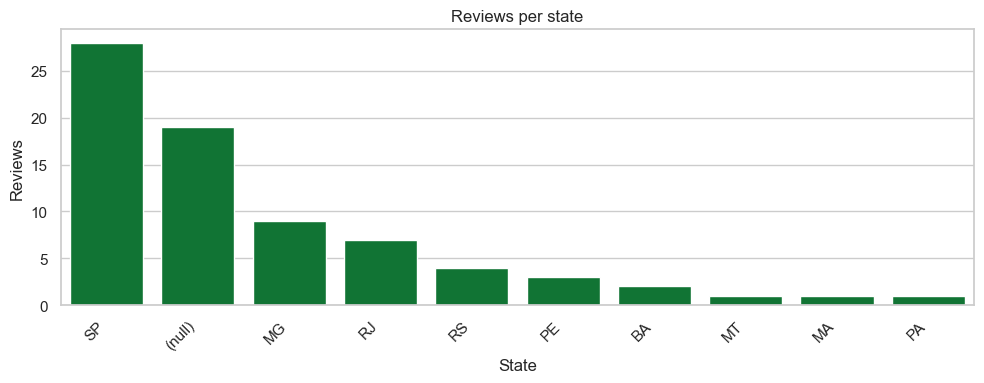

,reviews
state,
SP,28
(null),19
MG,9
RJ,7
RS,4
PE,3
BA,2
MT,1
MA,1


In [4]:
# Bar graph: reviews per state + display
state_counts = df["state"].fillna("(null)").value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=state_counts.index, y=state_counts.values)
ax.set_title("Reviews per state")
ax.set_xlabel("State")
ax.set_ylabel("Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(state_counts.rename("reviews").to_frame())

## 3) Rating Distributions
Here we look at overall review grade distribution (`nota`) and the presence/distribution of the more detailed sub-scores (`nota_custo`, `nota_atendimento`, `nota_comida`, `nota_ambiente`).

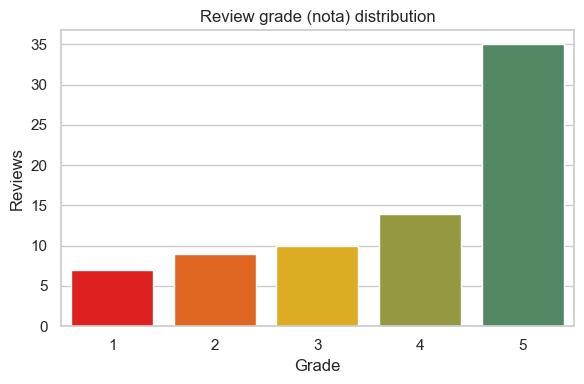

,count,pct_of_dataset
nota,,
1,7,9.33
2,9,12.00
3,10,13.33
4,14,18.67
5,35,46.67


In [5]:
# Bar graph: count of each review grade (1..5) + display with percentages
levels = [1, 2, 3, 4, 5]

nota_counts = df["nota"].value_counts(dropna=False).reindex(levels, fill_value=0)
nota_pct = (nota_counts / len(df) * 100).round(2)

plot_df = nota_counts.rename_axis("grade").reset_index(name="reviews")
# Seaborn treats categorical labels as strings in some cases; keep palette keys consistent
plot_df["grade"] = plot_df["grade"].astype(int).astype(str)
levels_str = [str(g) for g in levels]

palette = {str(g): grade_red_to_green(g) for g in levels}

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=plot_df,
    x="grade",
    y="reviews",
    order=levels_str,
    # Seaborn >=0.13 warns when passing `palette` without `hue`
    hue="grade",
    hue_order=levels_str,
    palette=palette,
    legend=False,
    dodge=False,
 )
ax.set_title("Review grade (nota) distribution")
ax.set_xlabel("Grade")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()

nota_summary = pd.DataFrame({"count": nota_counts.astype(int), "pct_of_dataset": nota_pct})
display(nota_summary)

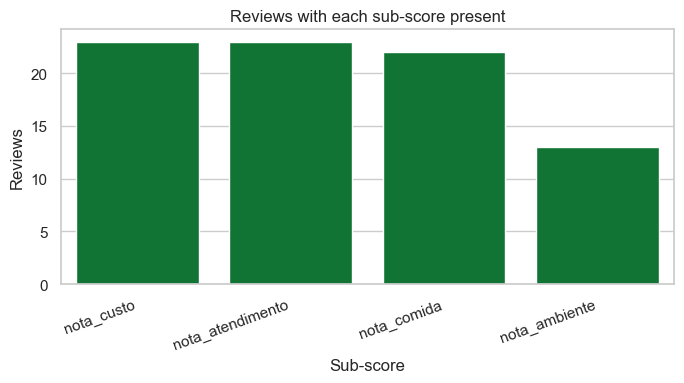

,reviews_with_value,pct_of_dataset
nota_custo,23,30.67
nota_atendimento,23,30.67
nota_comida,22,29.33
nota_ambiente,13,17.33


In [6]:
# Bar graph: how many reviews have each specific sub-score present + display
subscore_cols = ["nota_custo", "nota_atendimento", "nota_comida", "nota_ambiente"]
subscore_present = {col: int(df[col].notna().sum()) for col in subscore_cols if col in df.columns}
subscore_present = pd.Series(subscore_present).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=subscore_present.index, y=subscore_present.values)
ax.set_title("Reviews with each sub-score present")
ax.set_xlabel("Sub-score")
ax.set_ylabel("Reviews")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

n_reviews = len(df)
subscore_present_df = pd.DataFrame(
    {
        "reviews_with_value": subscore_present.astype(int),
        "pct_of_dataset": (subscore_present / n_reviews * 100).round(2) if n_reviews else np.nan,
    }
)

display(subscore_present_df)

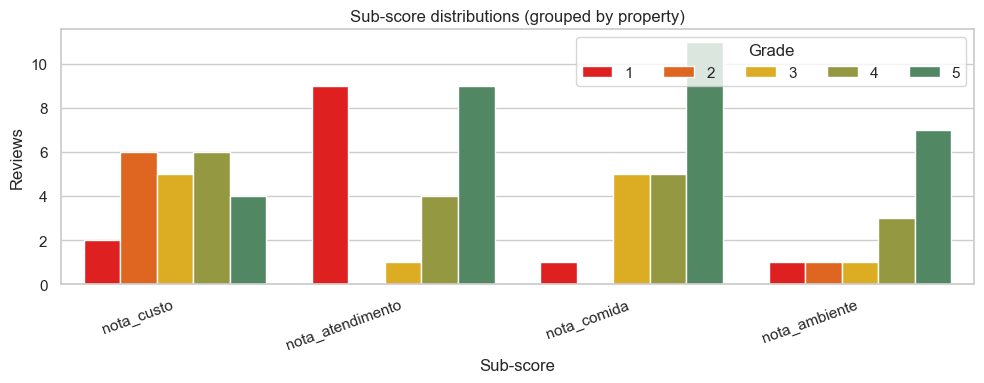

nota_custo (non-null reviews: 23)


,count,pct_of_non_null
grade,,
1,2,8.70
2,6,26.09
3,5,21.74
4,6,26.09
5,4,17.39


nota_atendimento (non-null reviews: 23)


,count,pct_of_non_null
grade,,
1,9,39.13
2,0,0.00
3,1,4.35
4,4,17.39
5,9,39.13


nota_comida (non-null reviews: 22)


,count,pct_of_non_null
grade,,
1,1,4.55
2,0,0.00
3,5,22.73
4,5,22.73
5,11,50.00


nota_ambiente (non-null reviews: 13)


,count,pct_of_non_null
grade,,
1,1,7.69
2,1,7.69
3,1,7.69
4,3,23.08
5,7,53.85


In [7]:
# Grouped bar graph: for each sub-score (property), compare grade counts (1..5) + display
subscore_cols = [c for c in ["nota_custo", "nota_atendimento", "nota_comida", "nota_ambiente"] if c in df.columns]
levels = [1, 2, 3, 4, 5]

# Build counts as: rows=property, cols=grade (counts only among non-null values)
counts_by_prop = {}
n_non_null_by_prop = {}
for col in subscore_cols:
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s = s[s.isin(levels)]
    counts = s.value_counts().reindex(levels, fill_value=0)
    counts_by_prop[col] = counts
    n_non_null_by_prop[col] = int(counts.sum())

counts_by_prop_df = pd.DataFrame(counts_by_prop, index=levels).T  # rows=property, cols=grade

# Long form for seaborn
plot_df = (
    counts_by_prop_df.reset_index()
    .rename(columns={"index": "property"})
    .melt(id_vars="property", var_name="grade", value_name="reviews")
)

# Use string hue labels so palette mapping is stable
plot_df["grade"] = plot_df["grade"].astype(int).astype(str)
levels_str = [str(g) for g in levels]
palette = {str(g): grade_red_to_green(g) for g in levels}

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=plot_df,
    x="property",
    y="reviews",
    hue="grade",
    order=subscore_cols,
    hue_order=levels_str,
    palette=palette,
)
ax.set_title("Sub-score distributions (grouped by property)")
ax.set_xlabel("Sub-score")
ax.set_ylabel("Reviews")
plt.xticks(rotation=20, ha="right")
ax.legend(title="Grade", ncols=5, loc="upper right")
plt.tight_layout()
plt.show()

# One display per property: count + % among reviews where the property is present (non-null)
for col in subscore_cols:
    denom = n_non_null_by_prop.get(col, 0)
    counts = counts_by_prop[col].astype(int)

    pct = (counts / denom * 100).round(2) if denom else (counts * np.nan)
    prop_df = pd.DataFrame(
        {
            "count": counts,
            "pct_of_non_null": pct,
        }
    )
    prop_df.index.name = "grade"

    print(f"{col} (non-null reviews: {denom})")
    display(prop_df)

## 4) Categories & Sponsorship
These fields help describe the context of the review (e.g., who the reviewer was with) and whether the review is marked as sponsored.

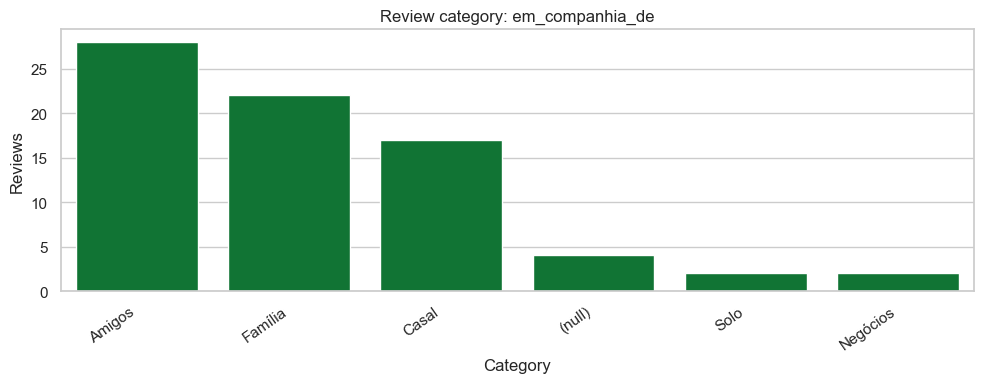

,count,pct_of_dataset
em_companhia_de,,
Amigos,28,37.33
Família,22,29.33
Casal,17,22.67
(null),4,5.33
Solo,2,2.67
Negócios,2,2.67


In [8]:
# Bar graph: em_companhia_de categories (including null) + display with percentages
comp_col = "em_companhia_de"
comp = df[comp_col].fillna("(null)")
comp_counts = comp.value_counts(dropna=False)
comp_pct = (comp_counts / len(df) * 100).round(2)

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=comp_counts.index.astype(str), y=comp_counts.values)
ax.set_title("Review category: em_companhia_de")
ax.set_xlabel("Category")
ax.set_ylabel("Reviews")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": comp_counts.astype(int), "pct_of_dataset": comp_pct}))

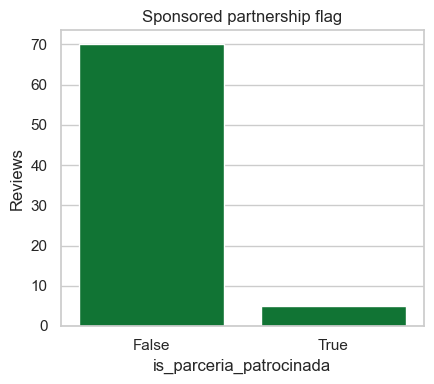

,count,pct_of_dataset
is_parceria_patrocinada,,
False,70,93.33
True,5,6.67


In [9]:
# Bar graph: is_parceria_patrocinada (True/False) + display with percentages
sponsor = df["is_parceria_patrocinada"].astype(bool)
sponsor_counts = sponsor.value_counts().rename(index={True: "True", False: "False"})
sponsor_pct = (sponsor_counts / len(df) * 100).round(2)

plt.figure(figsize=(4.5, 4))
ax = sns.barplot(x=sponsor_counts.index.astype(str), y=sponsor_counts.values)
ax.set_title("Sponsored partnership flag")
ax.set_xlabel("is_parceria_patrocinada")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": sponsor_counts.astype(int), "pct_of_dataset": sponsor_pct}))

## 5) Contributions
`contribuicoes` is a proxy for reviewer activity/engagement; we’ll inspect its distribution.

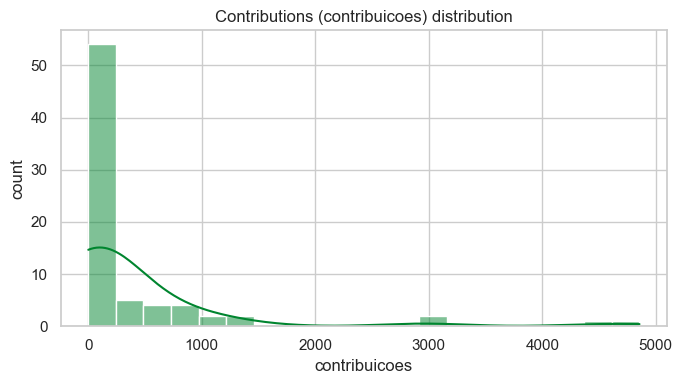

,count,min,p25,median,mean,p75,max
0,75,1,14.0,71.0,408.293333,369.0,4856


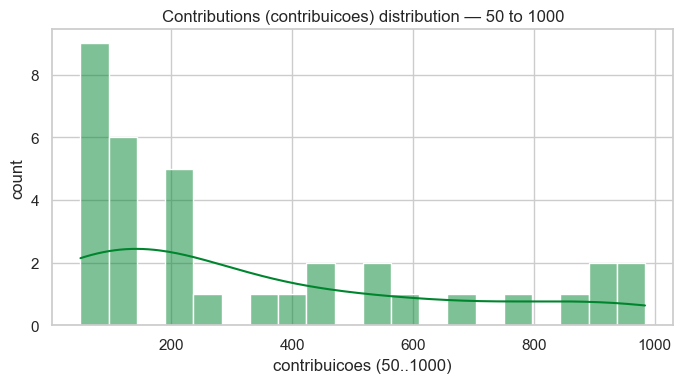

,count,min,p25,median,mean,p75,max,excluded_<50,excluded_>1000,pct_included
0,35,50,98.0,229.0,348.657143,542.0,984,34,6,46.67


In [10]:
# Histogram: contribuicoes + display
vals = df["contribuicoes"].dropna()

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals, bins=20, kde=True)
ax.set_title("Contributions (contribuicoes) distribution")
ax.set_xlabel("contribuicoes")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

contrib_summary = pd.DataFrame(
    {
        "count": [int(vals.shape[0])],
        "min": [vals.min() if not vals.empty else np.nan],
        "p25": [vals.quantile(0.25) if not vals.empty else np.nan],
        "median": [vals.median() if not vals.empty else np.nan],
        "mean": [vals.mean() if not vals.empty else np.nan],
        "p75": [vals.quantile(0.75) if not vals.empty else np.nan],
        "max": [vals.max() if not vals.empty else np.nan],
    }
)

display(contrib_summary)

# Histogram + display: contribuicoes (50..1000)
mask_50_1000 = df["contribuicoes"].notna() & df["contribuicoes"].between(50, 1000, inclusive="both")
vals_50_1000 = df.loc[mask_50_1000, "contribuicoes"]

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals_50_1000, bins=20, kde=True)
ax.set_title("Contributions (contribuicoes) distribution — 50 to 1000")
ax.set_xlabel("contribuicoes (50..1000)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

contrib_summary_50_1000 = pd.DataFrame(
    {
        "count": [int(vals_50_1000.shape[0])],
        "min": [vals_50_1000.min() if not vals_50_1000.empty else np.nan],
        "p25": [vals_50_1000.quantile(0.25) if not vals_50_1000.empty else np.nan],
        "median": [vals_50_1000.median() if not vals_50_1000.empty else np.nan],
        "mean": [vals_50_1000.mean() if not vals_50_1000.empty else np.nan],
        "p75": [vals_50_1000.quantile(0.75) if not vals_50_1000.empty else np.nan],
        "max": [vals_50_1000.max() if not vals_50_1000.empty else np.nan],
        "excluded_<50": [int((df["contribuicoes"] < 50).sum())],
        "excluded_>1000": [int((df["contribuicoes"] > 1000).sum())],
        "pct_included": [round((vals_50_1000.shape[0] / len(df) * 100), 2) if len(df) else np.nan],
    }
)

display(contrib_summary_50_1000)

## 6) Time Patterns
We use the extracted fields (`year`, `month`, `day_of_week`, `day_of_month`) to see when reviews were posted.

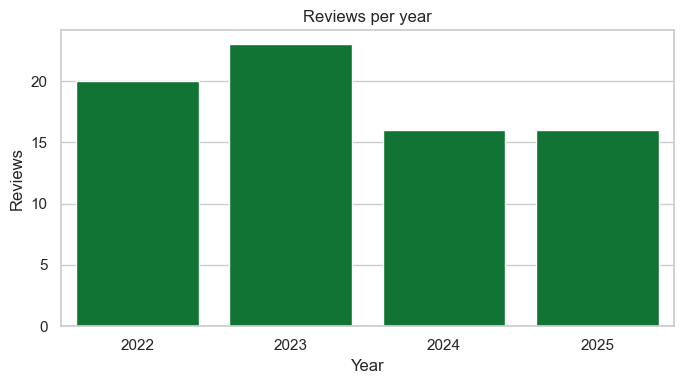

,count,pct_of_dataset
year,,
2022,20,26.67
2023,23,30.67
2024,16,21.33
2025,16,21.33


In [11]:
# Bar graph: year posting + display (with % of dataset)
year_counts = df["year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=year_counts.index.astype(str), y=year_counts.values)
ax.set_title("Reviews per year")
ax.set_xlabel("Year")
ax.set_ylabel("Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

year_summary = pd.DataFrame(
    {
        "count": year_counts.astype(int),
        "pct_of_dataset": (year_counts / len(df) * 100).round(2),
    }
)
year_summary.index.name = "year"
display(year_summary)

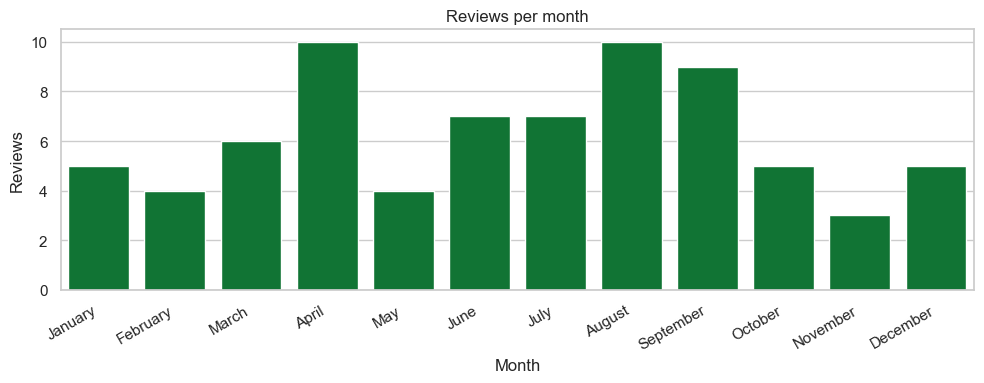

,reviews,pct_of_dataset
month,,
January,5,6.67
February,4,5.33
March,6,8.00
April,10,13.33
May,4,5.33
June,7,9.33
July,7,9.33
August,10,13.33
September,9,12.00


In [12]:
# Bar graph: month posting + display (with % of dataset) — use full month names
months = list(range(1, 13))

month_counts = (
    df["month"]
    .dropna()
    .astype(int)
    .value_counts()
    .reindex(months, fill_value=0)
    .sort_index()
)

# Map 1..12 -> "January".. "December" (locale depends on your environment)
month_labels = pd.to_datetime(pd.Series(month_counts.index.astype(str)), format="%m").dt.strftime("%B")
month_labels = month_labels.tolist()

# Plot
plt.figure(figsize=(10, 4))
ax = sns.barplot(x=month_labels, y=month_counts.values, order=month_labels)
ax.set_title("Reviews per month")
ax.set_xlabel("Month")
ax.set_ylabel("Reviews")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Display (fix index-alignment causing NaNs)
n_reviews_total = len(df)

pct_vals = ((month_counts / n_reviews_total) * 100).round(2).values

month_summary = pd.DataFrame(
    {
        "reviews": month_counts.astype(int).values,
        "pct_of_dataset": pct_vals,
    },
    index=month_labels,
)
month_summary.index.name = "month"
display(month_summary)

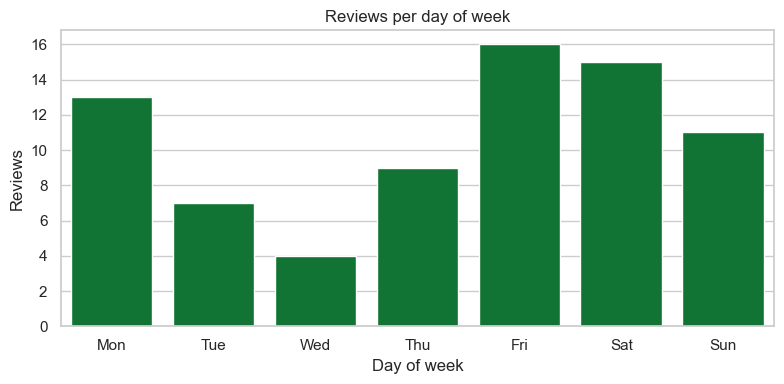

,reviews,pct_of_dataset
day_of_week_label,,
Mon,13,17.33
Tue,7,9.33
Wed,4,5.33
Thu,9,12.00
Fri,16,21.33
Sat,15,20.00
Sun,11,14.67


In [13]:
# Bar graph: day of week posting + display
# Prefer labels when available
if "day_of_week_label" in df.columns:
    dow = df["day_of_week_label"].fillna("(null)")
    order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun", "(null)"]
    dow_counts = dow.value_counts().reindex([x for x in order if x in dow.value_counts().index], fill_value=0)
else:
    dow_counts = df["day_of_week"].fillna(-1).astype(int).value_counts().sort_index()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=dow_counts.index.astype(str), y=dow_counts.values)
ax.set_title("Reviews per day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()

dow_summary = pd.DataFrame(
    {
        "reviews": dow_counts.astype(int),
        "pct_of_dataset": (dow_counts / len(df) * 100).round(2) if len(df) else np.nan,
    }
)
display(dow_summary)

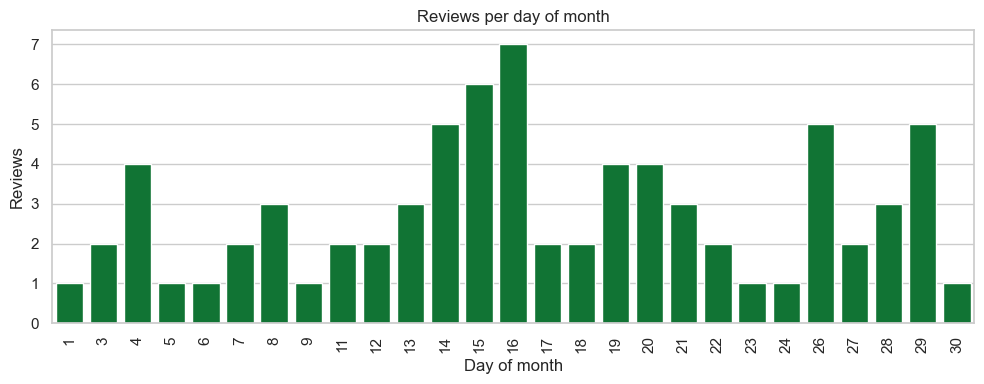

,reviews
day_of_month,
1,1
3,2
4,4
5,1
6,1
7,2
8,3
9,1
11,2


In [14]:
# Bar graph: day of month posting + display
dom_counts = df["day_of_month"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=dom_counts.index.astype(str), y=dom_counts.values)
ax.set_title("Reviews per day of month")
ax.set_xlabel("Day of month")
ax.set_ylabel("Reviews")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

display(dom_counts.rename("reviews").to_frame())

## 7) Text Lengths & Word Usage
We look at title/review lengths and then build word clouds to see the most common terms.

Note: word clouds are purely descriptive (they don’t capture sentiment or context).

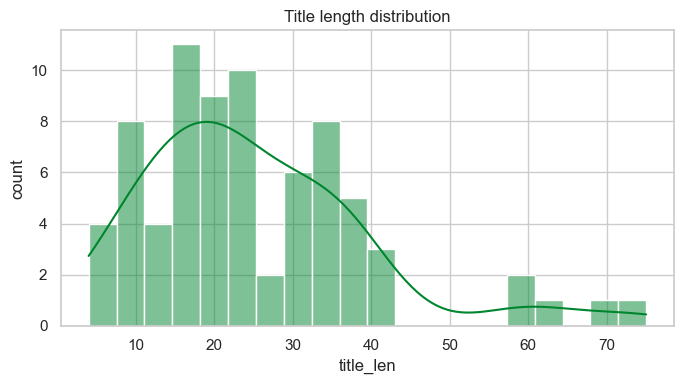

,count,mean,median,min,max
0,75,25.266667,22.0,4,75


In [15]:
# Histogram: title_len + display
vals = df["title_len"].dropna()

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals, bins=20, kde=True)
ax.set_title("Title length distribution")
ax.set_xlabel("title_len")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": [int(vals.shape[0])], "mean": [vals.mean()], "median": [vals.median()], "min": [vals.min()], "max": [vals.max()]}))

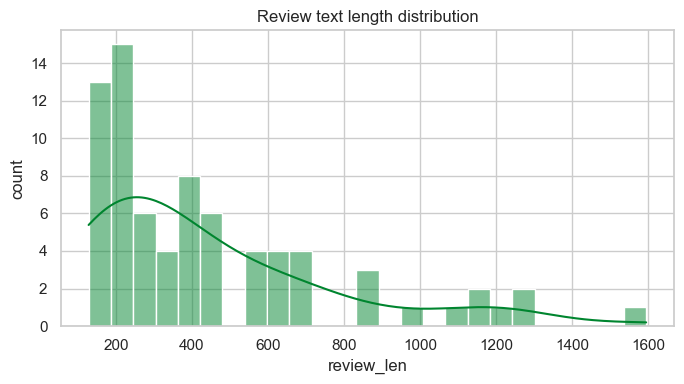

,count,mean,median,min,max
0,75,448.48,355.0,128,1595


In [16]:
# Histogram: review_len + display
vals = df["review_len"].dropna()

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals, bins=25, kde=True)
ax.set_title("Review text length distribution")
ax.set_xlabel("review_len")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": [int(vals.shape[0])], "mean": [vals.mean()], "median": [vals.median()], "min": [vals.min()], "max": [vals.max()]}))

In [17]:
# Display + observation: average review length
vals = df["review_len"].dropna()
mean_len = vals.mean() if not vals.empty else np.nan
median_len = vals.median() if not vals.empty else np.nan

summary = pd.DataFrame(
    {
        "metric": ["mean review_len", "median review_len"],
        "value": [mean_len, median_len],
    }
)

display(summary)

print(
    "Observation: If the mean is noticeably higher than the median, the dataset likely has a tail of very long reviews (right-skew). "
    "If mean and median are close, lengths are more symmetric."
)

,metric,value
0,mean review_len,448.48
1,median review_len,355.00


Observation: If the mean is noticeably higher than the median, the dataset likely has a tail of very long reviews (right-skew). If mean and median are close, lengths are more symmetric.


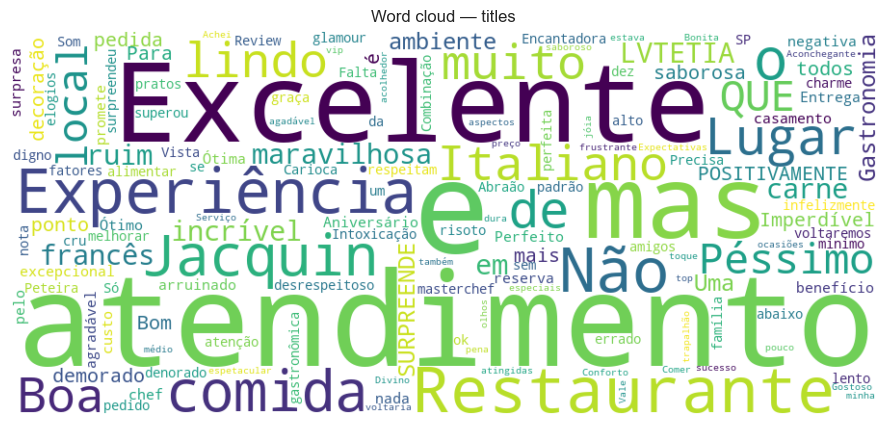

,title_wordcloud_source_chars
0,1969


In [18]:
# Word cloud: title (titulo)
text = " ".join(df["titulo"].dropna().astype(str).tolist())

if text.strip() == "":
    print("No title text available to build a word cloud.")
else:
    wc = WordCloud(width=900, height=400, background_color="white", stopwords=STOPWORDS, random_state=2026).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word cloud — titles")
    plt.show()

    display(pd.DataFrame({"title_wordcloud_source_chars": [len(text)]}))

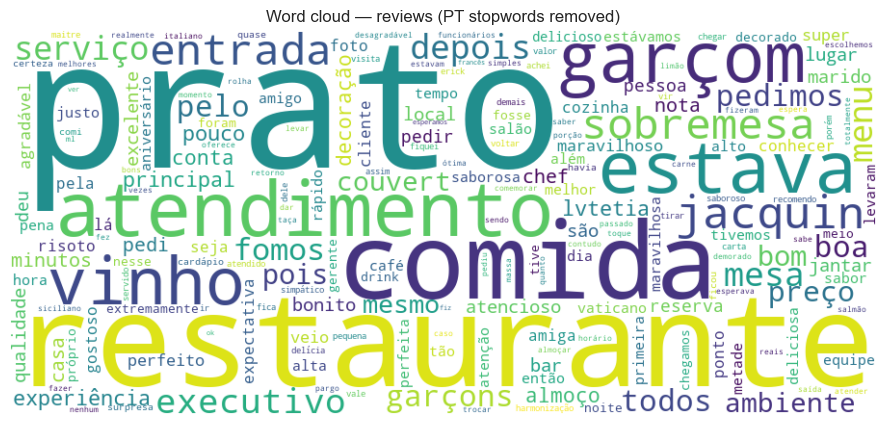

,review_wordcloud_source_chars
0,33710


In [19]:
# Word cloud: review text (review) — with Portuguese stop-words
text = " ".join(df["review"].dropna().astype(str).tolist())

# Common PT-BR stopwords (extend as needed)
pt_stopwords = {
    "a", "à", "ao", "aos", "as", "às", "o", "os", "um", "uma", "uns", "umas",
    "de", "da", "das", "do", "dos", "d", "dum", "duma",
    "e", "é", "em", "no", "nos", "na", "nas", "por", "para", "pra",
    "com", "sem", "sobre", "entre", "até", "desde", "após", "antes",
    "que", "quem", "quando", "onde", "como", "porque", "porquê", "por que",
    "se", "mas", "ou", "nem", "já", "ainda", "também", "muito", "muitos", "muita", "muitas",
    "mais", "menos", "bem", "mal", "só", "sim", "não",
    "eu", "me", "mim", "minha", "minhas", "meu", "meus",
    "você", "vocês", "te", "ti", "tua", "tuas", "teu", "teus",
    "ele", "ela", "eles", "elas", "lhe", "lhes", "seu", "seus", "sua", "suas",
    "nós", "nos", "nosso", "nossa", "nossos", "nossas",
    "um", "uma", "isso", "isto", "aquilo", "aqui", "aí", "ali",
    "este", "esta", "estes", "estas", "esse", "essa", "esses", "essas",
    "aquele", "aquela", "aqueles", "aquelas",
    "tudo", "nada", "algo", "algum", "alguma", "alguns", "algumas",
    "cada", "qual", "quais", "outro", "outra", "outros", "outras",
    "ser", "estar", "ter", "tinha", "tem", "têm", "foi", "fui", "era", "eram", "sou", "está", "estão",
}

# Combine existing WordCloud stopwords (mostly EN) with PT stopwords
stopwords_all = set(STOPWORDS) | pt_stopwords

if text.strip() == "":
    print("No review text available to build a word cloud.")
else:
    wc = WordCloud(
        width=900,
        height=400,
        background_color="white",
        stopwords=stopwords_all,
        collocations=False,  # reduces bigrams like "muito bom"
    ).generate(text.lower())

    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word cloud — reviews (PT stopwords removed)")
    plt.show()

    display(pd.DataFrame({"review_wordcloud_source_chars": [len(text)]}))

## 8) Correlations (Numeric Summary)
Finally, we compute a correlation matrix across engagement, ratings, time signals, and simple text-length features.

Note: We intentionally exclude direct correlations involving categorical encodings (like `em_companhia_de`) because the numeric codes are arbitrary and can be misleading.

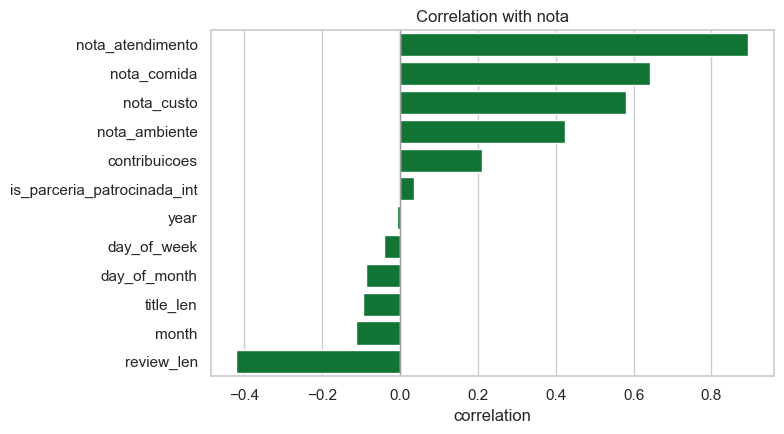

,feature,correlation_with_nota
0,nota_atendimento,0.895275
1,nota_comida,0.643540
2,nota_custo,0.580299
3,nota_ambiente,0.425114
4,contribuicoes,0.210113
5,is_parceria_patrocinada_int,0.036335
6,year,-0.006873
7,day_of_week,-0.041972
8,day_of_month,-0.087927
9,title_len,-0.095554


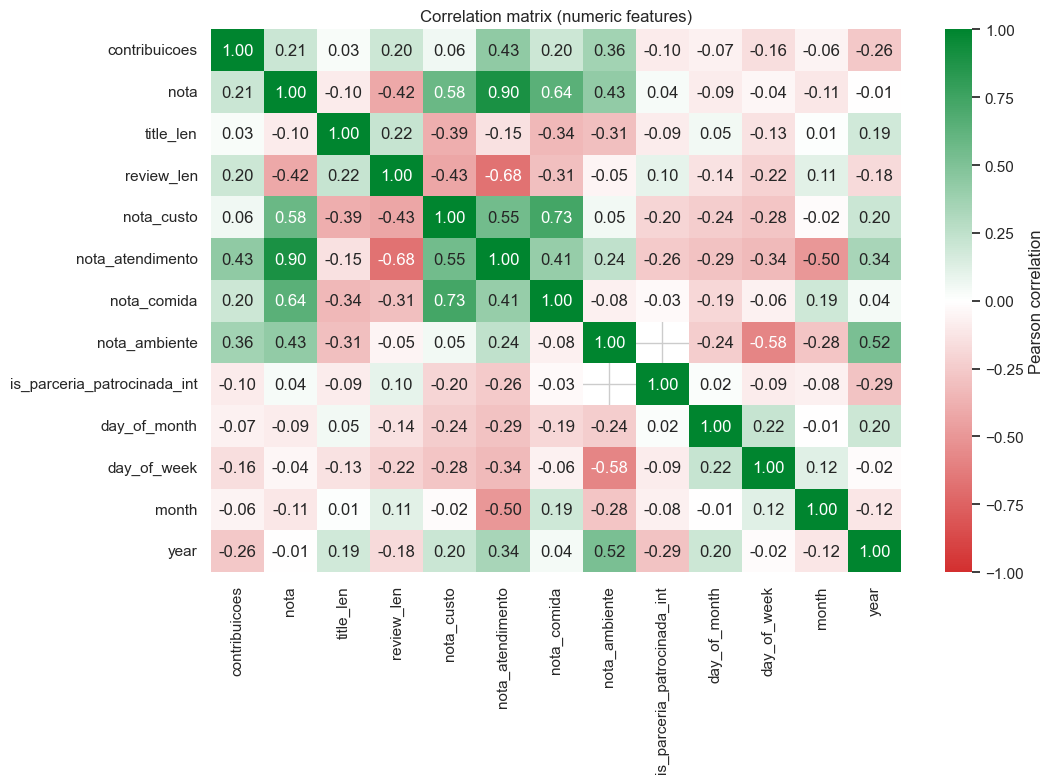

,feature_a,feature_b,correlation
0,nota,nota_atendimento,0.895275
1,nota_custo,nota_comida,0.728471
2,nota,nota_comida,0.643540
3,nota,nota_custo,0.580299
4,nota_custo,nota_atendimento,0.548945
5,nota_ambiente,year,0.517934
6,contribuicoes,nota_atendimento,0.434347
7,nota,nota_ambiente,0.425114
8,nota_atendimento,nota_comida,0.413055
9,contribuicoes,nota_ambiente,0.359883


In [20]:
from matplotlib.colors import LinearSegmentedColormap

# Correlation heatmap + sorted correlations vs nota (styled with DEFAULT_COLOR)

corr_cols = [
    "contribuicoes",
    "nota",
    "title_len",
    "review_len",
    "nota_custo",
    "nota_atendimento",
    "nota_comida",
    "nota_ambiente",
    "is_parceria_patrocinada_int",
    "day_of_month",
    "day_of_week",
    "month",
    "year",
]

# Keep only columns that actually exist to avoid KeyError
corr_cols = [c for c in corr_cols if c in df.columns]

corr_df = df[corr_cols].copy()
for c in corr_cols:
    corr_df[c] = pd.to_numeric(corr_df[c], errors="coerce")

corr = corr_df.corr()

# Ranked correlations vs the main target: nota
if "nota" in corr.columns:
    nota_corr = corr["nota"].drop(labels=["nota"]).sort_values(ascending=False)
else:
    nota_corr = pd.Series(dtype=float)

nota_corr_df = nota_corr.reset_index()
nota_corr_df.columns = ["feature", "correlation_with_nota"]

# 1) "Correlation with nota" graph
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=nota_corr_df,
    x="correlation_with_nota",
    y="feature",
    color=DEFAULT_COLOR,
)
ax.axvline(0, color="#9E9E9E", linewidth=1)
ax.set_title("Correlation with nota")
ax.set_xlabel("correlation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 2) feature and correlation_with_nota display
display(nota_corr_df)

# 3) correlation matrix
# Diverging colormap: negative=red, zero=white, positive=DEFAULT_COLOR
corr_cmap = LinearSegmentedColormap.from_list(
    "neg_white_pos_default",
    ["#D32F2F", "#FFFFFF", DEFAULT_COLOR],
    N=256,
)

plt.figure(figsize=(11, 8))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=corr_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson correlation"},
)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

# 4) feature_a vs feature_b display
mask_upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.where(mask_upper).stack().sort_values(ascending=False)

pairs_df = pairs.reset_index()
pairs_df.columns = ["feature_a", "feature_b", "correlation"]

display(pairs_df)

## 9) Images
We finish by looking at the distribution of image counts per review.

C:\Users\Ayrton\AppData\Local\Temp\ipykernel_18056\301530587.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


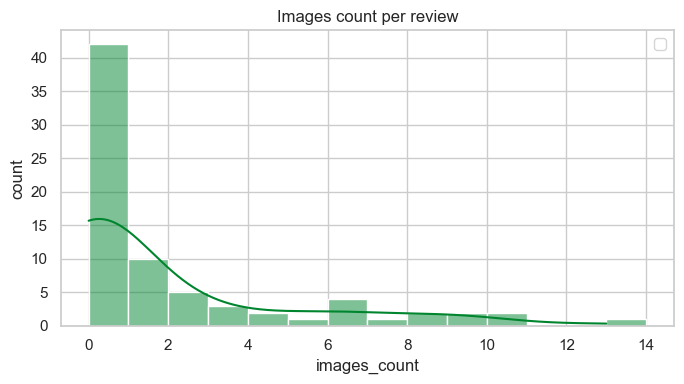

,count,mean,median,max,% with >=1
0,75,1.866667,0.0,13,44.0


In [21]:
# Histogram: images_count + display
vals = df["images_count"].fillna(0).astype(int)

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals, kde=True, bins=range(int(vals.max()) + 2) if len(vals) else 10)
ax.legend()
ax.set_title("Images count per review")
ax.set_xlabel("images_count")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "count": [int(vals.shape[0])],
            "mean": [vals.mean()],
            "median": [vals.median()],
            "max": [vals.max()],
            "% with >=1": [(vals.gt(0).mean() * 100)],
        }
    )
)

## 10) Behavior & Engagement (Additional Analyses)
The next analyses focus on how people behave when they review: how much they write, who they are with, whether a review is sponsored, and how engagement signals relate to ratings.

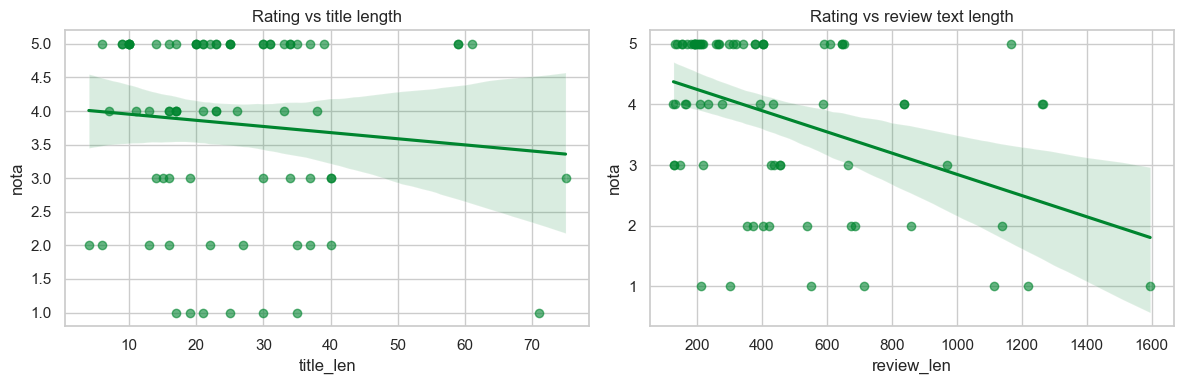

,metric,value
0,"corr(nota, title_len)",-0.095554
1,"corr(nota, review_len)",-0.420697


,review_len_bin,count,avg_nota
0,"(127.999, 193.4]",15,4.333333
1,"(193.4, 266.4]",15,4.466667
2,"(266.4, 405.0]",16,4.062500
3,"(405.0, 655.2]",14,3.571429
4,"(655.2, 1595.0]",15,2.600000


In [22]:
# Rating vs text length
# Relationship between rating and how much people write (title/review length)

df_len = df[["nota", "title_len", "review_len"]].dropna(subset=["nota"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(data=df_len, x="title_len", y="nota", scatter_kws={"alpha": 0.6}, ax=axes[0])
axes[0].set_title("Rating vs title length")
axes[0].set_xlabel("title_len")
axes[0].set_ylabel("nota")

sns.regplot(data=df_len, x="review_len", y="nota", scatter_kws={"alpha": 0.6}, ax=axes[1])
axes[1].set_title("Rating vs review text length")
axes[1].set_xlabel("review_len")
axes[1].set_ylabel("nota")

plt.tight_layout()
plt.show()

corrs = pd.DataFrame(
    {
        "metric": ["corr(nota, title_len)", "corr(nota, review_len)"],
        "value": [
            df_len[["nota", "title_len"]].corr().iloc[0, 1],
            df_len[["nota", "review_len"]].corr().iloc[0, 1],
        ],
    }
)

display(corrs)

# Optional binning for interpretability
bins = pd.qcut(df_len["review_len"], q=5, duplicates="drop")
binned = df_len.groupby(bins, observed=True).agg(count=("nota", "size"), avg_nota=("nota", "mean"))
display(binned.reset_index().rename(columns={"review_len": "review_len_bin"}))

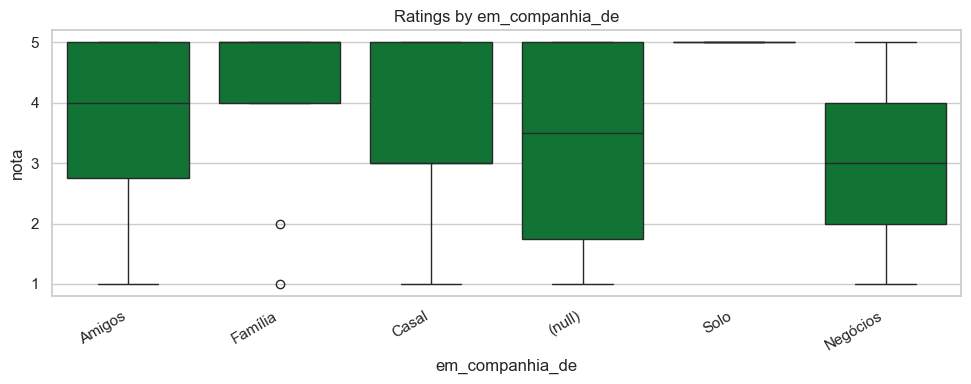

,em_companhia_de,count,avg_nota,median_nota
0,Amigos,28,3.607143,4.0
1,Família,22,4.363636,5.0
2,Casal,17,3.529412,3.0
3,(null),4,3.250000,3.5
4,Negócios,2,3.000000,3.0
5,Solo,2,5.000000,5.0


In [23]:
# Ratings by “who with” (em_companhia_de)
# Compare rating distributions across categories, including null.

cat = df["em_companhia_de"].fillna("(null)").astype(str)
df_cat = df[["nota"]].copy()
df_cat["em_companhia_de"] = cat

plt.figure(figsize=(10, 4))
order = df_cat["em_companhia_de"].value_counts().index.tolist()
sns.boxplot(data=df_cat, x="em_companhia_de", y="nota", order=order)
plt.title("Ratings by em_companhia_de")
plt.xlabel("em_companhia_de")
plt.ylabel("nota")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

summary = (
    df_cat.groupby("em_companhia_de", observed=True)
    .agg(count=("nota", "size"), avg_nota=("nota", "mean"), median_nota=("nota", "median"))
    .sort_values("count", ascending=False)
)
display(summary.reset_index())

,is_sponsored,count,avg_nota,median_nota,avg_review_len,pct_with_image
0,False,70,3.8,4.0,439.885714,44.285714
1,True,5,4.0,5.0,568.800000,40.000000


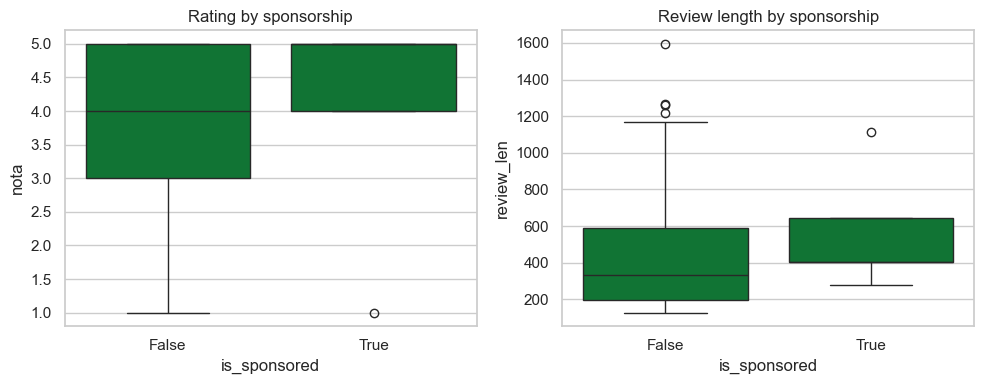

In [24]:
# Sponsorship effect (is_parceria_patrocinada)
# Compare rating, review length, and image rate between sponsored vs non-sponsored.

df_s = df.copy()
df_s["is_sponsored"] = df_s["is_parceria_patrocinada"].astype(bool)

summary = (
    df_s.groupby("is_sponsored", observed=True)
    .agg(
        count=("nota", "size"),
        avg_nota=("nota", "mean"),
        median_nota=("nota", "median"),
        avg_review_len=("review_len", "mean"),
        pct_with_image=("has_image", lambda s: float(s.mean() * 100)),
    )
    .reset_index()
)

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df_s, x="is_sponsored", y="nota", ax=axes[0])
axes[0].set_title("Rating by sponsorship")
axes[0].set_xlabel("is_sponsored")
axes[0].set_ylabel("nota")

sns.boxplot(data=df_s, x="is_sponsored", y="review_len", ax=axes[1])
axes[1].set_title("Review length by sponsorship")
axes[1].set_xlabel("is_sponsored")
axes[1].set_ylabel("review_len")

plt.tight_layout()
plt.show()

,contrib_tier,count,avg_contrib,avg_nota,avg_review_len,pct_with_image
0,"(0.999, 31.667]",25,8.08,3.28,427.24,28.0
1,"(31.667, 219.0]",25,76.72,3.64,496.48,32.0
2,"(219.0, 4856.0]",25,1140.08,4.52,421.72,72.0


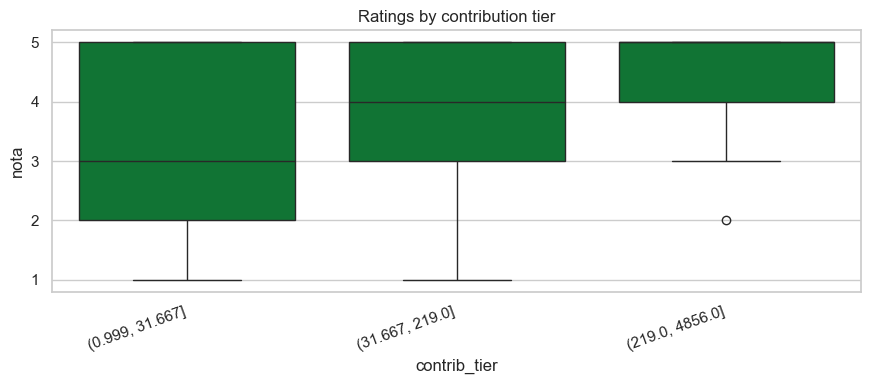

In [25]:
# Contribution tiers (contribuicoes)
# Bucket reviewers into quantiles and compare behavior + ratings.

df_c = df.copy()

# qcut can fail when there are too many repeated values; duplicates='drop' prevents that.
df_c["contrib_tier"] = pd.qcut(df_c["contribuicoes"], q=3, duplicates="drop")

summary = (
    df_c.groupby("contrib_tier", observed=True)
    .agg(
        count=("nota", "size"),
        avg_contrib=("contribuicoes", "mean"),
        avg_nota=("nota", "mean"),
        avg_review_len=("review_len", "mean"),
        pct_with_image=("has_image", lambda s: float(s.mean() * 100)),
    )
    .reset_index()
)

display(summary)

plt.figure(figsize=(9, 4))
order = summary["contrib_tier"].astype(str).tolist()
sns.boxplot(data=df_c, x=df_c["contrib_tier"].astype(str), y="nota", order=order)
plt.title("Ratings by contribution tier")
plt.xlabel("contrib_tier")
plt.ylabel("nota")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

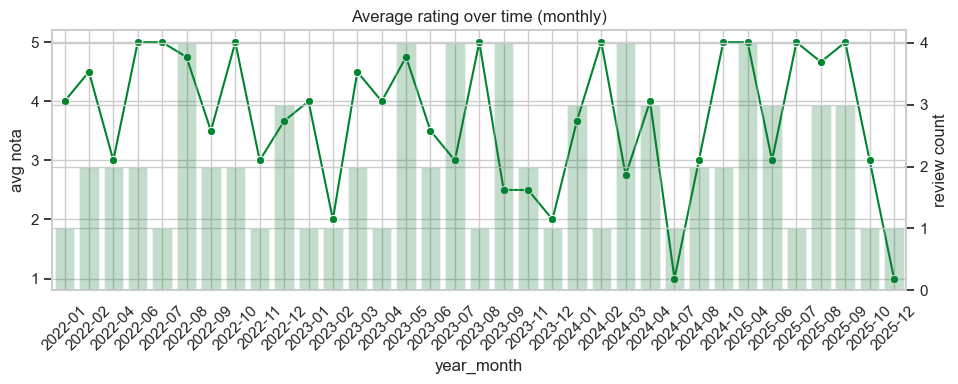

,year_month,count,avg_nota
0,2022-01,1,4.000000
1,2022-02,2,4.500000
2,2022-04,2,3.000000
3,2022-06,2,5.000000
4,2022-07,1,5.000000
5,2022-08,4,4.750000
6,2022-09,2,3.500000
7,2022-10,2,5.000000
8,2022-11,1,3.000000
9,2022-12,3,3.666667


In [26]:
# Time drift / seasonality in rating
# Track average rating over time (monthly), including review counts.

if "data_postagem" not in df.columns:
    print("No data_postagem column available.")
else:
    dt = pd.to_datetime(df["data_postagem"], errors="coerce")
    tmp = df.copy()
    tmp["year_month"] = dt.dt.to_period("M").astype(str)

    monthly = (
        tmp.dropna(subset=["year_month", "nota"])
        .groupby("year_month", observed=True)
        .agg(count=("nota", "size"), avg_nota=("nota", "mean"))
        .sort_index()
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=monthly, x="year_month", y="avg_nota", marker="o", ax=ax1)
    ax1.set_title("Average rating over time (monthly)")
    ax1.set_xlabel("year_month")
    ax1.set_ylabel("avg nota")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    sns.barplot(data=monthly, x="year_month", y="count", alpha=0.25, ax=ax2)
    ax2.set_ylabel("review count")

    plt.tight_layout()
    plt.show()

    display(monthly)

,is_weekend,count,avg_nota,avg_review_len,pct_with_image
0,False,49,3.734694,517.265306,48.979592
1,True,26,3.961538,318.846154,34.615385


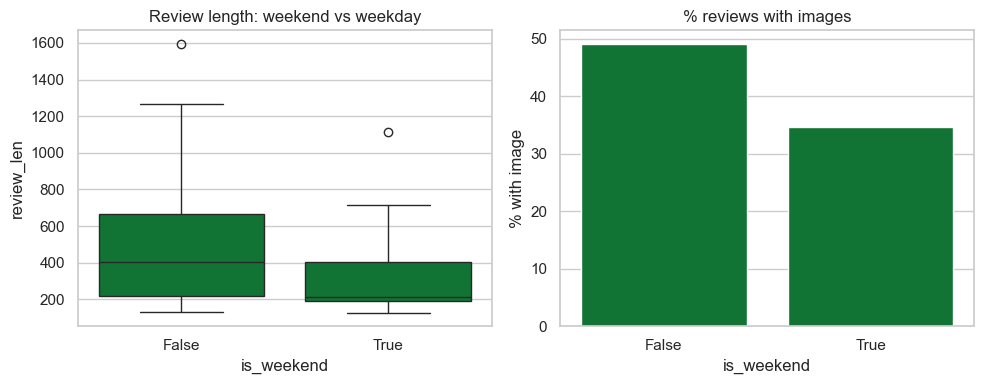

In [27]:
# Time vs engagement
# Compare weekend vs weekday behavior: review length and image rate.

df_t = df.copy()

if "day_of_week" not in df_t.columns:
    print("No day_of_week column available.")
else:
    df_t["is_weekend"] = df_t["day_of_week"].isin([5, 6])

    summary = (
        df_t.groupby("is_weekend", observed=True)
        .agg(
            count=("nota", "size"),
            avg_nota=("nota", "mean"),
            avg_review_len=("review_len", "mean"),
            pct_with_image=("has_image", lambda s: float(s.mean() * 100)),
        )
        .reset_index()
    )
    display(summary)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.boxplot(data=df_t, x="is_weekend", y="review_len", ax=axes[0])
    axes[0].set_title("Review length: weekend vs weekday")
    axes[0].set_xlabel("is_weekend")
    axes[0].set_ylabel("review_len")

    image_rate = df_t.groupby("is_weekend")["has_image"].mean() * 100
    sns.barplot(x=image_rate.index.astype(str), y=image_rate.values, ax=axes[1])
    axes[1].set_title("% reviews with images")
    axes[1].set_xlabel("is_weekend")
    axes[1].set_ylabel("% with image")

    plt.tight_layout()
    plt.show()

,subscore,count_non_null,corr_with_nota
1,nota_atendimento,23,0.895275
2,nota_comida,22,0.643540
0,nota_custo,23,0.580299
3,nota_ambiente,13,0.425114


,metric,value
0,"corr(nota, subscore_mean)",0.883628
1,mean gap (nota - subscore_mean),-0.340580
2,median gap (nota - subscore_mean),0.000000


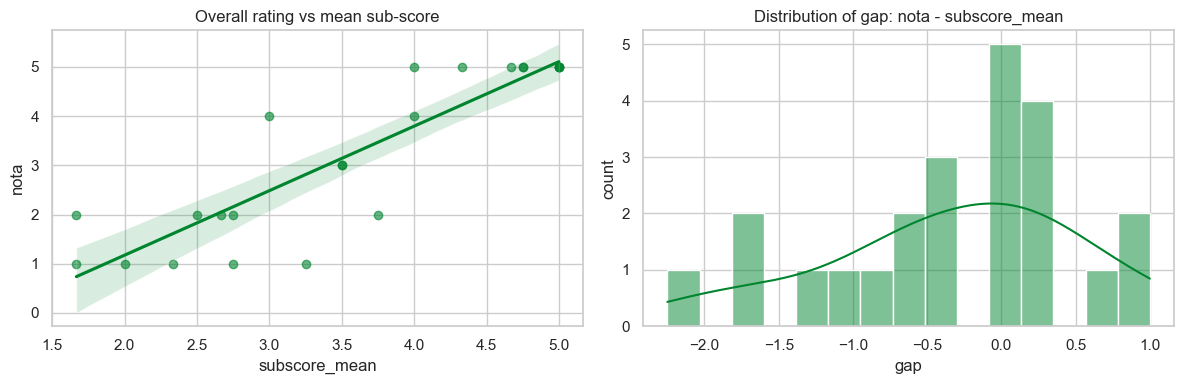

In [28]:
# Sub-score alignment
# How do the detailed sub-scores relate to overall rating (nota)?

sub_cols = ["nota_custo", "nota_atendimento", "nota_comida", "nota_ambiente"]
available = [c for c in sub_cols if c in df.columns]

if not available:
    print("No sub-score columns found.")
else:
    d = df[["nota"] + available].copy()
    # Keep only rows with at least one sub-score filled
    d = d.dropna(subset=["nota"]).copy()
    d["subscore_mean"] = d[available].mean(axis=1, skipna=True)
    d["gap_nota_minus_submean"] = d["nota"] - d["subscore_mean"]

    per_col_corr = []
    for c in available:
        per_col_corr.append(
            {
                "subscore": c,
                "count_non_null": int(d[["nota", c]].dropna().shape[0]),
                "corr_with_nota": d[["nota", c]].corr().iloc[0, 1],
            }
        )

    display(pd.DataFrame(per_col_corr).sort_values("corr_with_nota", ascending=False))

    display(
        pd.DataFrame(
            {
                "metric": [
                    "corr(nota, subscore_mean)",
                    "mean gap (nota - subscore_mean)",
                    "median gap (nota - subscore_mean)",
                ],
                "value": [
                    d[["nota", "subscore_mean"]].corr().iloc[0, 1],
                    d["gap_nota_minus_submean"].mean(),
                    d["gap_nota_minus_submean"].median(),
                ],
            }
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.regplot(data=d, x="subscore_mean", y="nota", scatter_kws={"alpha": 0.6}, ax=axes[0])
    axes[0].set_title("Overall rating vs mean sub-score")
    axes[0].set_xlabel("subscore_mean")
    axes[0].set_ylabel("nota")

    sns.histplot(d["gap_nota_minus_submean"].dropna(), bins=15, kde=True, ax=axes[1])
    axes[1].set_title("Distribution of gap: nota - subscore_mean")
    axes[1].set_xlabel("gap")
    axes[1].set_ylabel("count")

    plt.tight_layout()
    plt.show()

## 11) Text Analytics (Topics, Keywords, Sentiment)
These analyses look for recurring themes and language patterns in the review text, and how they relate to ratings.

They’re meant as exploratory signals (not “ground truth” sentiment).

c:\Users\Ayrton\Documents\Gitprojects\RestaurantReviewer\.venv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,cluster,count,avg_nota,top_terms
1,1,24,4.291667,"comida, excelente, maravilhoso, atendimento, e..."
0,0,20,3.250000,"pratos, depois, prato, mas, minutos, meu, serv..."
3,3,20,3.550000,"estava, bem, sobremesa, minha, veio, entrada, ..."
2,2,11,4.272727,"bem, comida, pena, restaurante, justo, preço, ..."


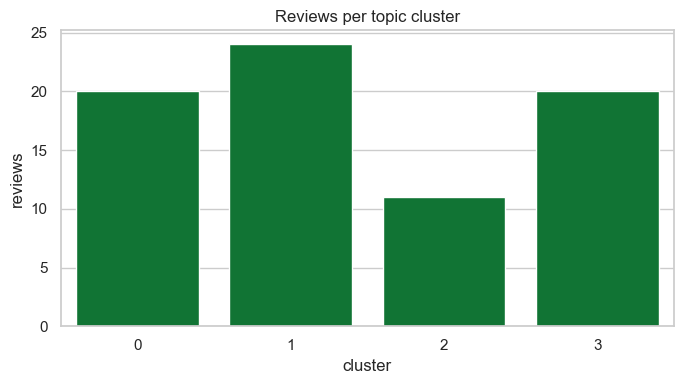

In [29]:
# Topic exploration (TF-IDF + clustering)
# Groups reviews into rough themes; shows top terms per cluster and average rating.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

texts = df["review"].dropna().astype(str)

if texts.empty:
    print("No review text available.")
else:
    # Minimal Portuguese-ish stopwords (kept small and explicit)
    pt_stop = {
        "a","o","os","as","um","uma","uns","umas",
        "de","do","da","dos","das","em","no","na","nos","nas",
        "e","ou","que","por","para","com","sem","mais","menos",
        "muito","muita","muitos","muitas","já","não","sim","ao","à","às",
        "foi","é","ser","estar","tem","tinha","têm","tive","vou","vai",
    }

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words=list(pt_stop),
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    )

    X = vectorizer.fit_transform(texts)

    # Choose a small number of clusters for a small dataset
    k = 4 if X.shape[0] >= 20 else 3
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X)

    feature_names = np.array(vectorizer.get_feature_names_out())

    # Map cluster labels back to df rows
    topic_df = df.loc[texts.index, ["nota"]].copy()
    topic_df["cluster"] = labels

    # Top terms per cluster
    top_terms = []
    for i in range(k):
        center = model.cluster_centers_[i]
        top_idx = center.argsort()[::-1][:10]
        top_terms.append(
            {
                "cluster": i,
                "top_terms": ", ".join(feature_names[top_idx].tolist()),
            }
        )

    cluster_summary = (
        topic_df.groupby("cluster", observed=True)
        .agg(count=("nota", "size"), avg_nota=("nota", "mean"))
        .reset_index()
        .merge(pd.DataFrame(top_terms), on="cluster", how="left")
        .sort_values("count", ascending=False)
    )

    display(cluster_summary)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=cluster_summary.sort_values("cluster"), x="cluster", y="count")
    plt.title("Reviews per topic cluster")
    plt.xlabel("cluster")
    plt.ylabel("reviews")
    plt.tight_layout()
    plt.show()

,token,high_count,low_count,log_odds(high-low)
463,preço,13,0,2.383409
1235,decoração,11,0,2.229259
828,chef,11,0,2.229259
650,excelente,9,0,2.046937
1006,perfeito,8,0,1.941577
921,maravilhoso,8,0,1.941577
548,este,6,0,1.690262
822,deliciosa,6,0,1.690262
767,justo,6,0,1.690262
1206,erick,5,0,1.536112


,token,high_count,low_count,log_odds(high-low)
1117,quando,1,12,-2.127450
1094,momento,0,4,-1.865086
1044,trocar,0,4,-1.865086
581,nada,1,8,-1.759725
1129,gente,0,3,-1.641942
174,tão,0,3,-1.641942
1146,padrão,0,3,-1.641942
567,nem,0,3,-1.641942
136,fiz,0,3,-1.641942
766,minutos,0,3,-1.641942


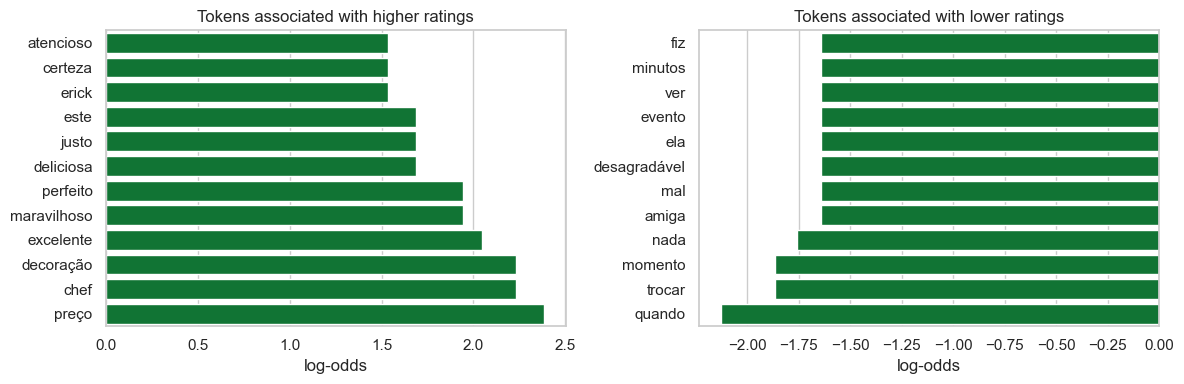

In [30]:
# Keyword ↔ rating association
# Compare token usage in high-rated vs low-rated reviews using a simple log-odds score.

import re
from collections import Counter

text_df = df[["nota", "review"]].dropna(subset=["nota", "review"]).copy()

high = text_df[text_df["nota"] >= 4]
low = text_df[text_df["nota"] <= 2]

if high.empty or low.empty:
    print("Not enough high or low reviews to compare (need at least one of each).")
else:
    def tokenize(s: str):
        s = s.lower()
        tokens = re.findall(r"\b[^\W\d_]{3,}\b", s, flags=re.UNICODE)
        return tokens

    high_counts = Counter()
    low_counts = Counter()

    for t in high["review"].astype(str):
        high_counts.update(tokenize(t))

    for t in low["review"].astype(str):
        low_counts.update(tokenize(t))

    vocab = set(high_counts) | set(low_counts)

    # Add-1 smoothing for stability on small datasets
    alpha = 1.0
    high_total = sum(high_counts.values()) + alpha * len(vocab)
    low_total = sum(low_counts.values()) + alpha * len(vocab)

    rows = []
    for w in vocab:
        hw = high_counts[w] + alpha
        lw = low_counts[w] + alpha
        log_odds = np.log(hw / high_total) - np.log(lw / low_total)
        rows.append({"token": w, "high_count": high_counts[w], "low_count": low_counts[w], "log_odds(high-low)": log_odds})

    assoc = pd.DataFrame(rows).sort_values("log_odds(high-low)", ascending=False)

    display(assoc.head(20))
    display(assoc.tail(20).sort_values("log_odds(high-low)", ascending=True))

    # Quick bar chart of top separators
    top_pos = assoc.head(12).sort_values("log_odds(high-low)")
    top_neg = assoc.tail(12)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(data=top_pos, x="log_odds(high-low)", y="token", ax=axes[0])
    axes[0].set_title("Tokens associated with higher ratings")
    axes[0].set_xlabel("log-odds")
    axes[0].set_ylabel("")

    sns.barplot(data=top_neg, x="log_odds(high-low)", y="token", ax=axes[1])
    axes[1].set_title("Tokens associated with lower ratings")
    axes[1].set_xlabel("log-odds")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

,metric,value
0,"corr(nota, sentiment_proxy)",0.599019
1,mean sentiment_proxy,0.032737
2,pct non-null,100.000000


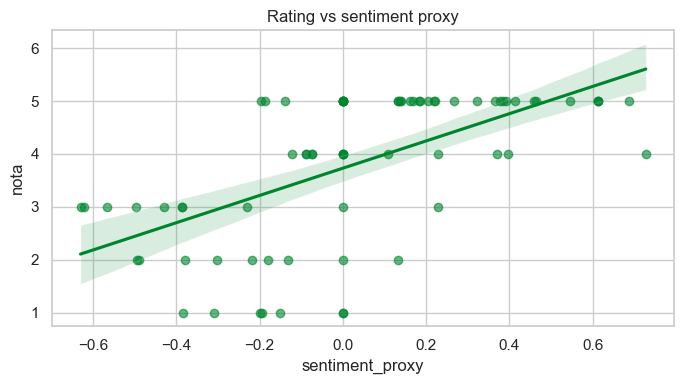

In [31]:
# Negativity/positivity proxy (simple lexicon score)
# A transparent heuristic sentiment score from a small explicit word list.

import re

sent_df = df[["nota", "review"]].dropna(subset=["nota", "review"]).copy()

pos_words = {
    "ótimo", "otimo", "excelente", "bom", "boa", "maravilhoso", "maravilhosa",
    "perfeito", "perfeita", "delicioso", "deliciosa", "incrível", "incrivel",
    "recomendo", "adoro", "amei", "sensacional", "top", "gostei",
}
neg_words = {
    "ruim", "péssimo", "pessimo", "horrível", "horrivel", "demorado", "demora",
    "caro", "cara", "frio", "fria", "decepcionante", "decepção", "decepcao",
    "nunca", "jamais", "não", "nao", "recomendo", "recomendar", "mal",
}

# Note: "recomendo" appears in both sets sometimes via negation; this is a heuristic.

def tokenize(s: str):
    s = s.lower()
    return re.findall(r"\b[^\W\d_]{2,}\b", s, flags=re.UNICODE)

scores = []
for idx, row in sent_df.iterrows():
    tokens = tokenize(str(row["review"]))
    if not tokens:
        scores.append(np.nan)
        continue

    pos = sum(1 for t in tokens if t in pos_words)
    neg = sum(1 for t in tokens if t in neg_words)

    # Normalize by length so long reviews don't automatically score higher magnitude
    score = (pos - neg) / max(1, np.sqrt(len(tokens)))
    scores.append(score)

sent_df["sentiment_proxy"] = scores

summary = pd.DataFrame(
    {
        "metric": ["corr(nota, sentiment_proxy)", "mean sentiment_proxy", "pct non-null"],
        "value": [
            sent_df[["nota", "sentiment_proxy"]].dropna().corr().iloc[0, 1],
            sent_df["sentiment_proxy"].mean(),
            float(sent_df["sentiment_proxy"].notna().mean() * 100),
        ],
    }
)

display(summary)

plt.figure(figsize=(7, 4))
sns.regplot(data=sent_df, x="sentiment_proxy", y="nota", scatter_kws={"alpha": 0.6})
plt.title("Rating vs sentiment proxy")
plt.xlabel("sentiment_proxy")
plt.ylabel("nota")
plt.tight_layout()
plt.show()

## Embeddings map (PCA)

**What are embeddings?**
Embeddings are a way to represent text (like a review) as a long list of numbers. Those numbers are created so that texts with similar meaning end up with similar numbers. This lets a computer compare pieces of text by “meaning similarity” instead of only matching exact words.

**What is PCA (dimension reduction)?**
Embeddings often have many dimensions (sometimes hundreds or thousands). PCA (Principal Component Analysis) is a technique that compresses those many dimensions down into fewer dimensions while keeping as much of the overall structure as possible. Here we reduce everything down to **2 dimensions** so we can visualize it on a flat chart.

**What does this chart show?**
Each dot is one row from the dataset (one item in the dataframe). The dot’s position comes from that item’s embedding after PCA reduction:
- Dots **closer together** tend to have **more similar content/meaning**.
- Dots **far apart** tend to be **less similar**.
- The axes (PCA 1 and PCA 2) do **not** have a human label like “service” or “food”; they are just the two directions that best summarize the variation in the embedding space.

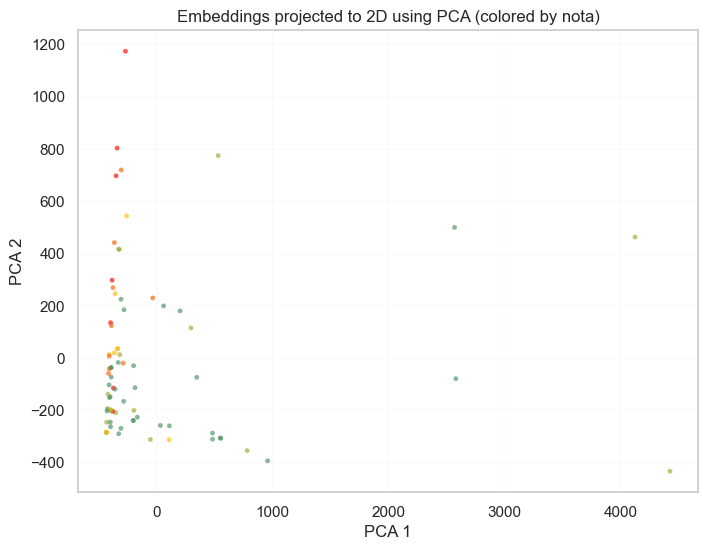

In [32]:
# PCA scatter plot of embeddings (2D projection) — color dots by rating (red->green)

required_cols = {"pca_1", "pca_2"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"Missing columns for PCA plot: {sorted(missing)}")

if "nota" in df.columns:
    point_colors = df["nota"].apply(grade_red_to_green).tolist()
else:
    point_colors = DEFAULT_COLOR

plt.figure(figsize=(8, 6))
plt.scatter(
    df["pca_1"],
    df["pca_2"],
    s=12,
    c=point_colors,
    alpha=0.65,
    linewidths=0,
    edgecolors="black",
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Embeddings projected to 2D using PCA (colored by nota)")
plt.grid(True, linewidth=0.3, alpha=0.3)
plt.show()

That plot looks correct and matches what we’d expect from a 2D PCA projection of text embeddings.

- Most dots are packed on the left: those items have embeddings that are broadly similar to each other (similar “meaning” patterns in the reviews).
- The few dots far to the right (very large PCA 1) are outliers: reviews whose content is unusually different from the bulk (often because they’re about a very specific topic, are written in a very different style/language, or contain atypical tokens like lots of numbers/URLs).
- The exact numeric values on “PCA 1” and “PCA 2” don’t have a direct human interpretation; what matters is relative distance (closer = more similar, farther = less similar).

## Embeddings map (TruncatedSVD)

**What is TruncatedSVD (dimension reduction)?**
TruncatedSVD is a linear dimension-reduction method very similar in spirit to PCA, and it’s commonly used when the data is sparse (e.g., TF‑IDF) or when you want an efficient linear compression.

**What does this chart show?**
Each dot is one row from the dataset. The dot’s position comes from that item’s embedding after TruncatedSVD reduction to **2 dimensions** (SVD 1 and SVD 2).

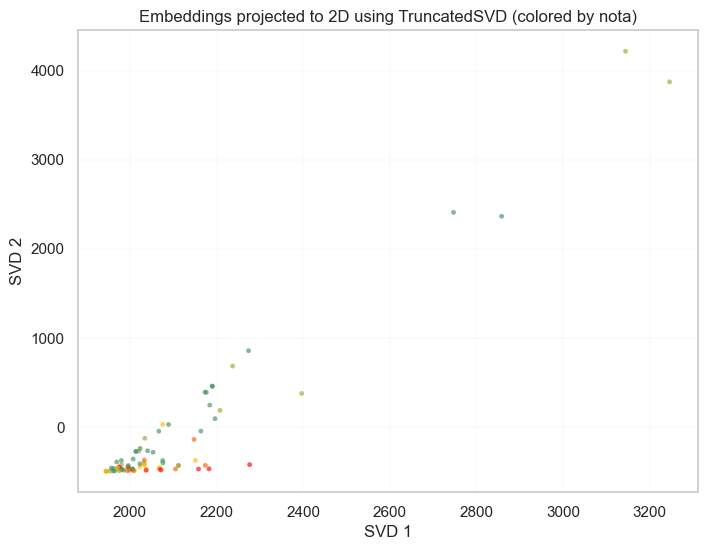

In [33]:
# TruncatedSVD scatter plot of embeddings (2D projection) — color dots by rating (red->green)

required_cols = {"svd_1", "svd_2"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"Missing columns for TruncatedSVD plot: {sorted(missing)}")

if "nota" in df.columns:
    point_colors = df["nota"].apply(grade_red_to_green).tolist()
else:
    point_colors = DEFAULT_COLOR

plt.figure(figsize=(8, 6))
plt.scatter(
    df["svd_1"],
    df["svd_2"],
    s=12,
    c=point_colors,
    alpha=0.65,
    linewidths=0,
    edgecolors="black",
)
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")
plt.title("Embeddings projected to 2D using TruncatedSVD (colored by nota)")
plt.grid(True, linewidth=0.3, alpha=0.3)
plt.show()

That plot looks correct for a 2D TruncatedSVD projection of embeddings.

- TruncatedSVD is a **linear** reduction (like PCA), so you often see a dense “main cloud” plus some outliers.
- Dots close together indicate reviews with similar embedding directions under this linear compression.
- As with PCA, the axes are not directly interpretable; relative distance and overall structure are what matter.

## Embeddings map (t-SNE)

**What is t-SNE (dimension reduction)?**
t-SNE (t-distributed Stochastic Neighbor Embedding) is a non-linear technique designed to keep **similar items close together** when projecting to 2 dimensions. It’s often good for revealing local clusters in embedding data.

**What does this chart show?**
Each dot is one row from the dataset. The dot’s position comes from the item’s embedding after t-SNE reduction to **2 dimensions** (t-SNE 1 and t-SNE 2).

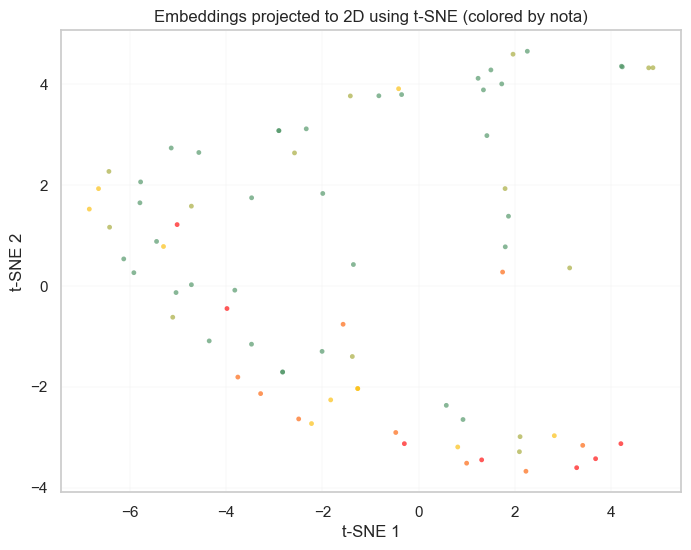

In [34]:
# t-SNE scatter plot of embeddings (2D projection) — color dots by rating (red->green)

required_cols = {"tsne_1", "tsne_2"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"Missing columns for t-SNE plot: {sorted(missing)}")

if "nota" in df.columns:
    point_colors = df["nota"].apply(grade_red_to_green).tolist()
else:
    point_colors = DEFAULT_COLOR

plt.figure(figsize=(8, 6))
plt.scatter(
    df["tsne_1"],
    df["tsne_2"],
    s=12,
    c=point_colors,
    alpha=0.65,
    linewidths=0,
    edgecolors="black",
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Embeddings projected to 2D using t-SNE (colored by nota)")
plt.grid(True, linewidth=0.3, alpha=0.3)
plt.show()

That plot looks plausible for a t-SNE-based 2D embedding map.

- t-SNE is optimized to preserve **local neighborhoods**, so tight groups of points often indicate reviews that are highly similar in content.
- The distance between far-apart clusters is *not* reliably meaningful in t-SNE; focus more on whether you see clear “islands” and how mixed the colors (nota) are inside each island.
- If you see isolated single points far away, they are likely text outliers (very unusual content, language, formatting, or tokens).

## Embeddings map (NMF)

**What is NMF (dimension reduction)?**
NMF (Non-negative Matrix Factorization) is a technique that decomposes embeddings into a small set of **non-negative** components. In practice it often produces “parts-based” components that can be easier to interpret as coarse themes.

**What does this chart show?**
Each dot is one row from the dataset. The dot’s position is the item’s embedding after NMF reduction to **2 dimensions** (NMF 1 and NMF 2). As usual, closer dots tend to have more similar content.

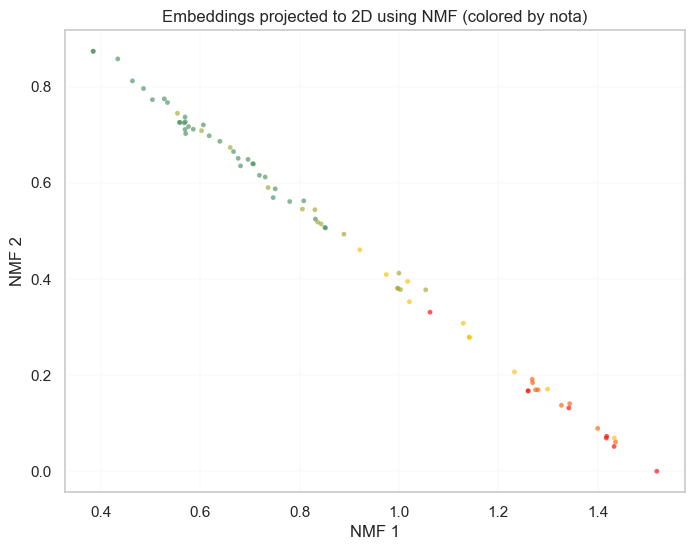

In [35]:
# NMF scatter plot of embeddings (2D projection) — color dots by rating (red->green)

required_cols = {"nmf_1", "nmf_2"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"Missing columns for NMF plot: {sorted(missing)}")

if "nota" in df.columns:
    point_colors = df["nota"].apply(grade_red_to_green).tolist()
else:
    point_colors = DEFAULT_COLOR

plt.figure(figsize=(8, 6))
plt.scatter(
    df["nmf_1"],
    df["nmf_2"],
    s=12,
    c=point_colors,
    alpha=0.65,
    linewidths=0,
    edgecolors="black",
)
plt.xlabel("NMF 1")
plt.ylabel("NMF 2")
plt.title("Embeddings projected to 2D using NMF (colored by nota)")
plt.grid(True, linewidth=0.3, alpha=0.3)
plt.show()

That plot looks plausible for an NMF-based 2D projection of text embeddings.

- Dots that cluster together likely share a similar mixture of the underlying latent “components” that NMF discovered (often interpretable as coarse topics/themes).
- Compared to PCA/SVD, NMF uses non-negative components, so the geometry can look more “parts-based” (points often spread along a few dominant directions).
- As with the other projections, the absolute axis values are not directly meaningful; focus on relative proximity and whether the color gradient (nota) shows any structure.

## Outliers

**What are outliers?**
Outliers are observations that are *unusually different* from the rest of the dataset under some feature representation.

In this notebook, when we talk about outliers we mean reviews whose **combined feature vector** (ratings + metadata + embeddings) looks very far from the “typical” review. This can happen because:
- The review text is genuinely unusual (different language, formatting, lots of numbers/URLs, very niche topic).
- The review is extremely short/empty, or extremely long.
- There are scraping/normalization artifacts (weird encodings, duplicated boilerplate text, missing fields).

### Why remove outliers before PCA / TruncatedSVD?
PCA and TruncatedSVD are **linear** methods that find directions capturing the largest variance in the input space. A small number of extreme points can dominate that variance and “pull” the projection, which often compresses the main cluster and makes the 2D map less representative of the bulk of the data.

Removing (or at least identifying) outliers before these **linear** projections can:
- Make the 2D visualization easier to read for the main population.
- Reduce the chance that PCA/SVD components are mostly explaining a tiny handful of extreme points.

### Why *not* apply outlier removal to other reductions (t-SNE, NMF)?
- **t-SNE** is non-linear and focused on *local neighborhoods*. Outliers usually end up isolated naturally, and removing points can change neighborhood relationships and cluster layout in hard-to-predict ways. Also, t-SNE is inherently stochastic/sensitive to hyperparameters; a “cleaned” run may look different mostly because of those sensitivities.
- **NMF** is constrained (non-negative) and often used to expose *rare components/topics*. What looks like an outlier can be a legitimate “rare theme” that NMF should keep. Also, the non-negativity scaling step already changes geometry substantially.

### Outlier detection methods we’ll compare
We’ll detect outliers in the *same high-dimensional feature space* that feeds PCA/SVD, using:

- **Robust covariance (EllipticEnvelope / MCD)**: fits a robust Gaussian ellipsoid (covariance estimate) and flags points with unusually large Mahalanobis distance.
- **One-Class SVM**: learns a boundary around the “normal” region (kernel method) and labels points outside it as anomalies.
- **One-Class SVM (SGD)**: a large-scale/linear variant trained with stochastic gradient descent; faster but less expressive than kernel One-Class SVM.
- **Isolation Forest**: isolates anomalies by random partitioning; outliers tend to require fewer splits to isolate.
- **Local Outlier Factor (LOF)**: compares each point’s local density to its neighbors; points in sparse neighborhoods relative to neighbors are flagged.

If a method is stochastic, we use a fixed seed for reproducibility.

In [36]:
# DataFrames with only the 2D projection columns

pca_cols = [c for c in ["pca_1", "pca_2", "nota"] if c in df.columns]
svd_cols = [c for c in ["svd_1", "svd_2", "nota"] if c in df.columns]

if len(pca_cols) != 3:
    raise KeyError(f"Expected PCA columns ['pca_1','pca_2','nota'], found: {pca_cols}")
if len(svd_cols) != 3:
    raise KeyError(f"Expected SVD columns ['svd_1','svd_2','nota'], found: {svd_cols}")

df_pca_only = df[pca_cols].copy()
df_svd_only = df[svd_cols].copy()

display(df_pca_only.head())
display(df_svd_only.head())

,pca_1,pca_2,nota
0,-268.22370,1174.01840,1
1,-432.04156,-283.55298,3
2,111.05185,-258.76828,5
3,-400.28308,-146.98930,5
4,-283.38608,-164.98956,5


,svd_1,svd_2,nota
0,2276.4583,-420.299200,1
1,1946.8635,-494.053920,3
2,2089.2434,29.898315,5
3,1981.6622,-471.207060,5
4,2007.6747,-357.068270,5


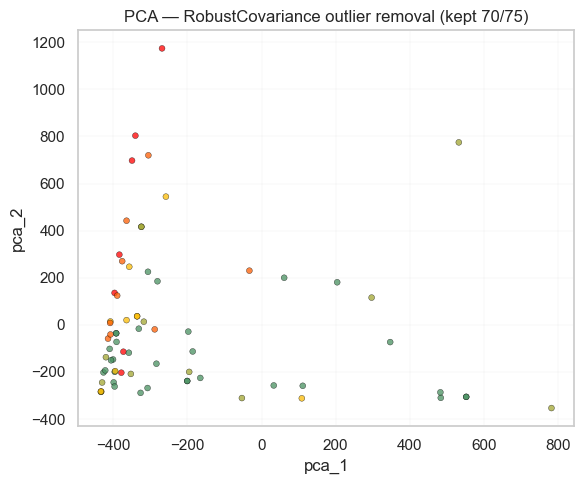

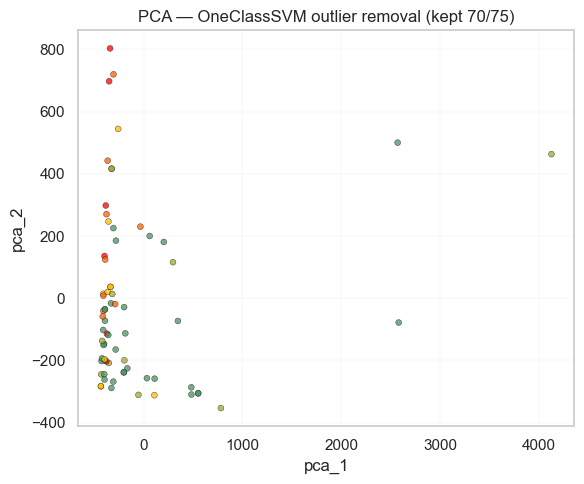

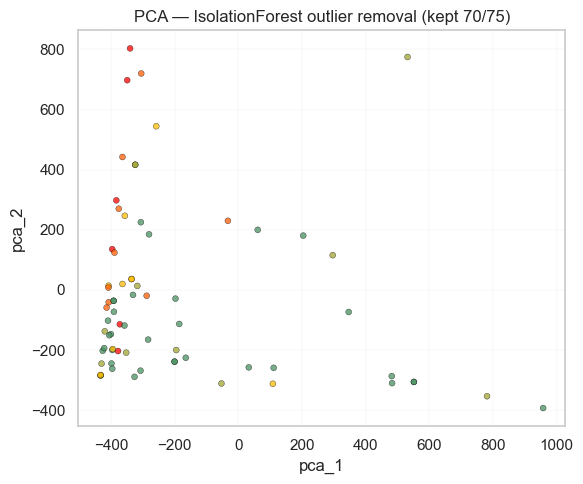

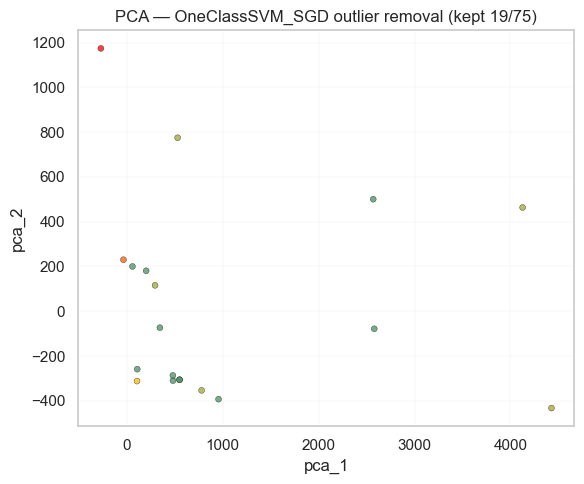

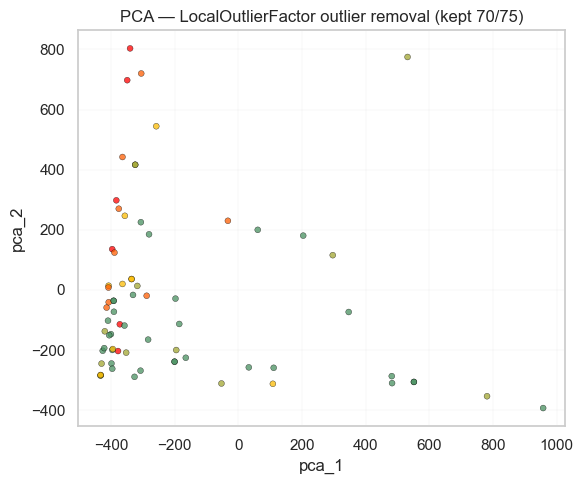

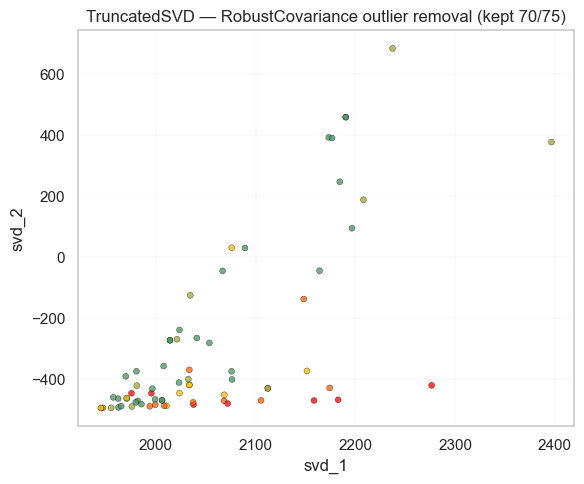

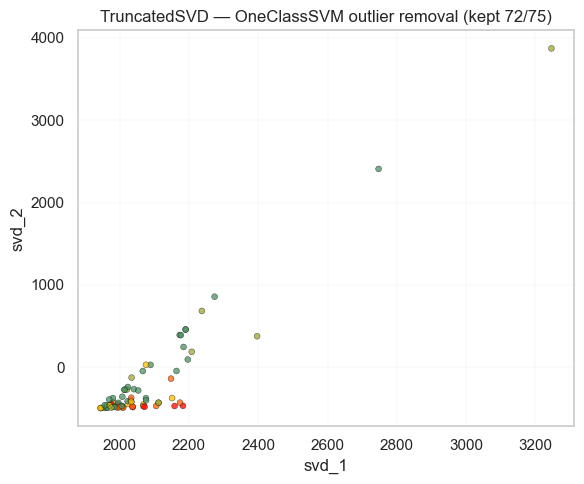

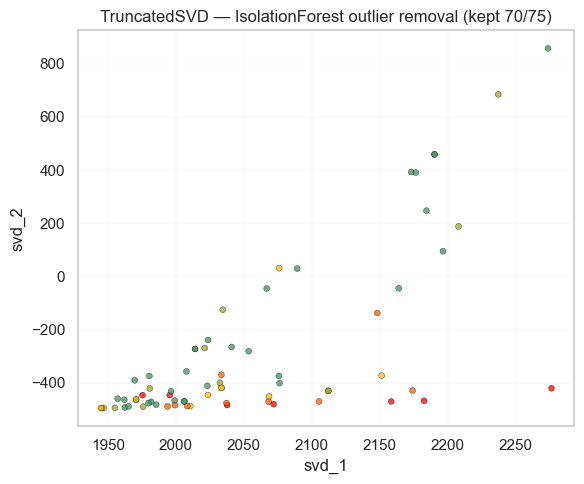

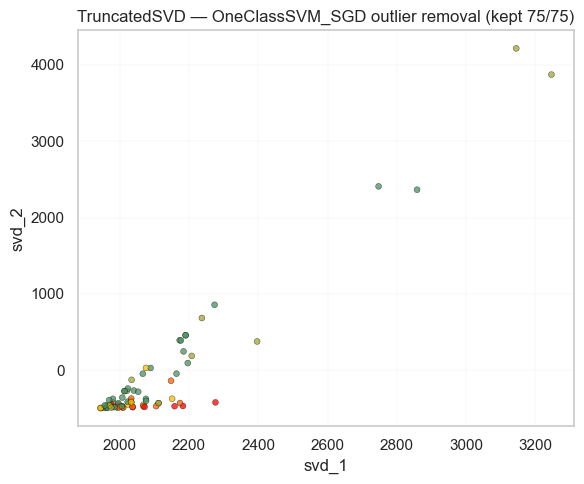

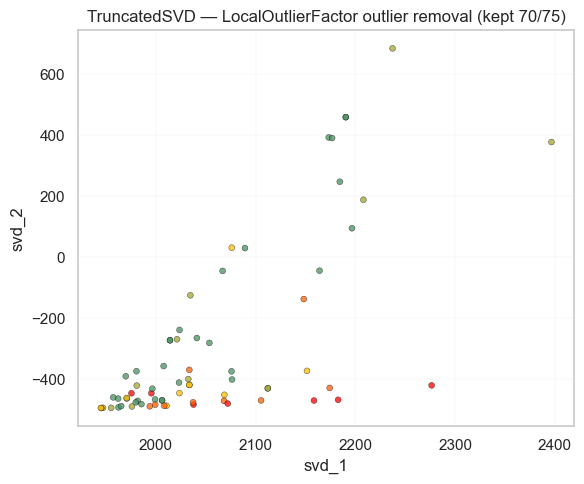

In [37]:
from sklearn.covariance import EllipticEnvelope
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import SGDOneClassSVM

SEED = 42  # fixed seed for any stochastic methods

# Best-effort: also fix global RNGs (only if available in this notebook)
try:
    import numpy as np

    np.random.seed(SEED)
except Exception:
    pass

try:
    import random

    random.seed(SEED)
except Exception:
    pass

for name, df_proj in [("PCA", df_pca_only), ("TruncatedSVD", df_svd_only)]:
    # Use only the projection coordinates for outlier detection (keep "nota" for plotting/analysis)
    feature_cols = list(df_proj.columns[:2])  # e.g., ["pca_1","pca_2"] or ["svd_1","svd_2"]
    X = df_proj[feature_cols].to_numpy(dtype=float)

    # Outlier configs (small dataset -> keep contamination low)
    contamination = 0.06
    nu = 0.06

    methods = {
        # stochastic -> random_state fixed
        "RobustCovariance": EllipticEnvelope(contamination=contamination, random_state=SEED),
        # deterministic given X (no random_state param)
        "OneClassSVM": OneClassSVM(kernel="rbf", nu=nu, gamma="scale"),
        # stochastic -> random_state fixed; n_jobs=1 improves determinism across runs
        "IsolationForest": IsolationForest(
            contamination=contamination,
            random_state=SEED,
            n_estimators=300,
            n_jobs=1,
        ),
    }

    # One-class SVM (SGD) if available; otherwise fall back to a linear OneClassSVM
    try:
        # stochastic -> random_state fixed
        methods["OneClassSVM_SGD"] = SGDOneClassSVM(
            nu=nu, random_state=SEED, max_iter=2000, tol=1e-3
        )
    except Exception:
        methods["OneClassSVM_SGD"] = OneClassSVM(kernel="linear", nu=nu)

    # LOF is deterministic given X (no random_state param)
    lof = LocalOutlierFactor(
        n_neighbors=min(20, max(5, len(df_proj) - 1)),
        contamination=contamination,
    )

    cleaned_by_method = {}

    for method_name, model in methods.items():
        labels_ = model.fit_predict(X)  # 1=inlier, -1=outlier
        inlier_mask = labels_ == 1

        # Keep ALL columns (including "nota")
        df_clean = df_proj.loc[inlier_mask].copy()
        cleaned_by_method[method_name] = df_clean

        # Save a named dataset for later use
        proj_key = "pca" if name.upper() == "PCA" else "svd"
        globals()[f"df_{proj_key}_{method_name.lower()}_clean"] = df_clean

        # Scatter plot (after outlier removal), colored by "nota"
        colors = df_clean["nota"].apply(grade_red_to_green) if "nota" in df_clean.columns else DEFAULT_COLOR

        plt.figure(figsize=(6, 5))
        plt.scatter(
            df_clean[feature_cols[0]],
            df_clean[feature_cols[1]],
            s=18,
            c=colors,
            alpha=0.75,
            linewidths=0.3,
            edgecolors="black",
        )
        plt.xlabel(feature_cols[0])
        plt.ylabel(feature_cols[1])
        plt.title(
            f"{name} — {method_name} outlier removal (kept {inlier_mask.sum()}/{len(inlier_mask)})"
        )
        plt.grid(True, linewidth=0.3, alpha=0.35)
        plt.tight_layout()
        plt.show()

    # LOF (handled separately)
    lof_labels = lof.fit_predict(X)  # 1=inlier, -1=outlier
    lof_inlier_mask = lof_labels == 1
    df_clean_lof = df_proj.loc[lof_inlier_mask].copy()
    cleaned_by_method["LocalOutlierFactor"] = df_clean_lof

    proj_key = "pca" if name.upper() == "PCA" else "svd"
    globals()[f"df_{proj_key}_localoutlierfactor_clean"] = df_clean_lof

    colors_lof = (
        df_clean_lof["nota"].apply(grade_red_to_green)
        if "nota" in df_clean_lof.columns
        else DEFAULT_COLOR
    )

    plt.figure(figsize=(6, 5))
    plt.scatter(
        df_clean_lof[feature_cols[0]],
        df_clean_lof[feature_cols[1]],
        s=18,
        c=colors_lof,
        alpha=0.75,
        linewidths=0.3,
        edgecolors="black",
    )
    plt.xlabel(feature_cols[0])
    plt.ylabel(feature_cols[1])
    plt.title(
        f"{name} — LocalOutlierFactor outlier removal (kept {lof_inlier_mask.sum()}/{len(lof_inlier_mask)})"
    )
    plt.grid(True, linewidth=0.3, alpha=0.35)
    plt.tight_layout()
    plt.show()